# Analysis Code

## ET/BT Synchronization

Load cleaned ET and BT exports for one participant, check sampling rates (ET via `gaze_capture_time`, BT via `raw_timestamp`), upsample BT onto the ET `raw_timestamp` grid within each segment, merge into one dataframe, and verify the ET rate on `gaze_capture_time` after sync.

In [43]:
import re
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

In [44]:
PARTICIPANT_ID = "001"
CLEANED_DIR = Path(r"C:\Users\experiment\Desktop\cleaned_classified_P01-16_18_05_2026")
SAVE_SYNCHRONIZED = True

In [ ]:
def normalize_pid(participant_id):
    pid = str(participant_id).strip()
    if not pid.isdigit():
        raise ValueError(f"Participant ID must be numeric, got: {participant_id!r}")
    return pid.zfill(3)


def load_cleaned_pair(participant_id, cleaned_dir):
    pid = normalize_pid(participant_id)
    et_path = cleaned_dir / f"clean_{pid}_ET.csv"
    bt_path = cleaned_dir / f"clean_{pid}_BT.csv"

    missing = [str(path) for path in (et_path, bt_path) if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing cleaned file(s):\n- " + "\n- ".join(missing))

    et_df = pd.read_csv(et_path, low_memory=False)
    bt_df = pd.read_csv(bt_path, low_memory=False)

    for frame in (et_df, bt_df):
        if "participant_id" in frame.columns:
            frame["participant_id"] = frame["participant_id"].astype(str).str.zfill(3)
        if "raw_timestamp" not in frame.columns:
            raise KeyError("Both cleaned files must contain 'raw_timestamp'.")
        frame["raw_timestamp"] = pd.to_numeric(frame["raw_timestamp"], errors="coerce")

    if "gaze_capture_time" not in et_df.columns:
        raise KeyError("ET file must contain 'gaze_capture_time'.")
    et_df["gaze_capture_time"] = pd.to_numeric(et_df["gaze_capture_time"], errors="coerce")

    return pid, et_path, bt_path, et_df, bt_df


def et_sampling_rate_summary(df):
    if "gaze_capture_time" not in df.columns:
        raise KeyError("ET sampling rate requires 'gaze_capture_time'.")

    t = pd.to_numeric(df["gaze_capture_time"], errors="coerce").dropna().sort_values()
    dt_ns = t.diff().dropna()
    dt_ns = dt_ns[dt_ns > 0]

    median_dt_ns = dt_ns.median()
    return pd.DataFrame(
        [
            {
                "stream": "ET",
                "time_col": "gaze_capture_time",
                "n_rows": len(t),
                "unique_timestamps": t.nunique(),
                "median_dt": median_dt_ns,
                "median_dt_unit": "ns",
                "median_sampling_rate_hz": 1e9 / median_dt_ns if pd.notna(median_dt_ns) else np.nan,
            }
        ]
    )


def bt_sampling_rate_summary(df):
    if "raw_timestamp" not in df.columns:
        raise KeyError("BT sampling rate requires 'raw_timestamp'.")

    t = pd.to_numeric(df["raw_timestamp"], errors="coerce").dropna().sort_values()
    dt_ms = t.diff().dropna()
    dt_ms = dt_ms[dt_ms > 0]

    median_dt_ms = dt_ms.median()
    return pd.DataFrame(
        [
            {
                "stream": "BT",
                "time_col": "raw_timestamp",
                "n_rows": len(t),
                "unique_timestamps": t.nunique(),
                "median_dt": median_dt_ms,
                "median_dt_unit": "ms",
                "median_sampling_rate_hz": 1000.0 / median_dt_ms if pd.notna(median_dt_ms) else np.nan,
            }
        ]
    )


def get_bt_column_groups(bt_df, group_cols=("participant_id", "condition_number", "trial_number")):
    exclude = {"raw_timestamp", *group_cols}
    discrete_passthrough = {
        "model_name",
        "model_rot_deg",
        "LeftFootArea",
        "RightFootArea",
        "source_file",
        "segment_label",
        "sampling_rate_hz",
        "dt",
        "dt_ms",
    }

    continuous_cols = []
    discrete_cols = []
    for col in bt_df.columns:
        if col in exclude:
            continue
        if col.startswith("bad_sample_") or col.startswith("is_interpolated_"):
            discrete_cols.append(col)
            continue
        if col in discrete_passthrough:
            discrete_cols.append(col)
            continue
        if pd.api.types.is_numeric_dtype(bt_df[col]):
            continuous_cols.append(col)
        else:
            discrete_cols.append(col)
    return continuous_cols, discrete_cols


def prepare_bt_segment(bt_segment, continuous_cols, discrete_cols):
    bt_seg = bt_segment.copy()
    bt_seg["raw_timestamp"] = pd.to_numeric(bt_seg["raw_timestamp"], errors="coerce")
    bt_seg = bt_seg.dropna(subset=["raw_timestamp"]).sort_values("raw_timestamp")

    agg_map = {}
    for col in continuous_cols:
        if col in bt_seg.columns:
            agg_map[col] = "mean"
    for col in discrete_cols:
        if col in bt_seg.columns:
            agg_map[col] = "first"

    if not agg_map:
        raise ValueError("No BT columns available for synchronization.")

    return (
        bt_seg.groupby("raw_timestamp", as_index=False, dropna=False)
        .agg(agg_map)
        .sort_values("raw_timestamp")
        .reset_index(drop=True)
    )


def interpolate_bt_to_et(et_segment, bt_segment, continuous_cols, discrete_cols):
    et_sync = et_segment.copy().sort_values("raw_timestamp").reset_index(drop=True)
    et_t = pd.to_numeric(et_sync["raw_timestamp"], errors="coerce").to_numpy(dtype=float)

    bt_unique = prepare_bt_segment(bt_segment, continuous_cols, discrete_cols)
    src_t = bt_unique["raw_timestamp"].to_numpy(dtype=float)

    nearest_idx = None
    nearest_support = np.zeros(len(et_sync), dtype=bool)

    if len(src_t) >= 1:
        right_idx = np.searchsorted(src_t, et_t, side="left")
        prev_idx = np.clip(right_idx - 1, 0, len(src_t) - 1)
        next_idx = np.clip(right_idx, 0, len(src_t) - 1)

        prev_t = src_t[prev_idx]
        next_t = src_t[next_idx]
        prev_dist = np.abs(et_t - prev_t)
        next_dist = np.abs(et_t - next_t)
        choose_prev = prev_dist <= next_dist
        nearest_idx = np.where(choose_prev, prev_idx, next_idx)
        nearest_support = np.isfinite(et_t) & (et_t >= src_t[0]) & (et_t <= src_t[-1])

    for col in continuous_cols:
        out_col = f"bt_{col}"
        if col not in bt_unique.columns:
            et_sync[out_col] = np.nan
            continue

        src_v = pd.to_numeric(bt_unique[col], errors="coerce").to_numpy(dtype=float)
        valid = np.isfinite(src_t) & np.isfinite(src_v)
        if valid.sum() < 2:
            et_sync[out_col] = np.nan
            continue

        t_valid = src_t[valid]
        v_valid = src_v[valid]
        within = np.isfinite(et_t) & (et_t >= t_valid[0]) & (et_t <= t_valid[-1])

        interp_values = np.full(len(et_sync), np.nan, dtype=float)
        interp_values[within] = np.interp(et_t[within], t_valid, v_valid)
        et_sync[out_col] = interp_values

    for col in discrete_cols:
        out_col = f"bt_{col}"
        if col not in bt_unique.columns:
            et_sync[out_col] = np.nan
            continue

        src_series = bt_unique[col]
        if pd.api.types.is_numeric_dtype(src_series):
            carried = np.full(len(et_sync), np.nan, dtype=float)
            if nearest_idx is not None and nearest_support.any():
                src_values = pd.to_numeric(src_series, errors="coerce").to_numpy(dtype=float)
                carried[nearest_support] = src_values[nearest_idx[nearest_support]]
            et_sync[out_col] = carried
        else:
            carried = np.full(len(et_sync), np.nan, dtype=object)
            if nearest_idx is not None and nearest_support.any():
                src_values = src_series.astype(object).to_numpy()
                carried[nearest_support] = src_values[nearest_idx[nearest_support]]
            et_sync[out_col] = carried

    return et_sync


def synchronize_et_bt(et_df, bt_df, group_cols=("participant_id", "condition_number", "trial_number")):
    group_cols = list(group_cols)
    missing = [col for col in group_cols if col not in et_df.columns or col not in bt_df.columns]
    if missing:
        raise KeyError(f"Missing grouping column(s) in ET or BT data: {missing}")

    continuous_cols, discrete_cols = get_bt_column_groups(bt_df, group_cols=group_cols)
    bt_groups = {
        key if isinstance(key, tuple) else (key,): sub.copy()
        for key, sub in bt_df.groupby(group_cols, sort=True, dropna=False)
    }

    synced_segments = []
    empty_bt = bt_df.iloc[0:0].copy()

    for key, et_segment in et_df.groupby(group_cols, sort=True, dropna=False):
        key = key if isinstance(key, tuple) else (key,)
        bt_segment = bt_groups.get(key, empty_bt)
        synced_segments.append(
            interpolate_bt_to_et(et_segment, bt_segment, continuous_cols, discrete_cols)
        )

    return pd.concat(synced_segments, axis=0, ignore_index=True)


def build_synchronized_dataframe(participant_id, cleaned_dir):
    pid, et_path, bt_path, et_df, bt_df = load_cleaned_pair(participant_id, cleaned_dir)

    et_pre = et_sampling_rate_summary(et_df)
    bt_pre = bt_sampling_rate_summary(bt_df)

    sync_df = synchronize_et_bt(et_df, bt_df)
    et_post = et_sampling_rate_summary(sync_df)

    et_pre_hz = et_pre["median_sampling_rate_hz"].iloc[0]
    et_post_hz = et_post["median_sampling_rate_hz"].iloc[0]

    rate_report = pd.DataFrame(
        [
            {
                "stage": "pre_sync",
                "stream": "ET",
                "time_col": "gaze_capture_time",
                "median_sampling_rate_hz": et_pre_hz,
            },
            {
                "stage": "pre_sync",
                "stream": "BT",
                "time_col": "raw_timestamp",
                "median_sampling_rate_hz": bt_pre["median_sampling_rate_hz"].iloc[0],
            },
            {
                "stage": "post_sync",
                "stream": "ET",
                "time_col": "gaze_capture_time",
                "median_sampling_rate_hz": et_post_hz,
            },
        ]
    )
    rate_report["rate_diff_from_et_pre_hz"] = rate_report["median_sampling_rate_hz"] - et_pre_hz

    meta = {
        "pid": pid,
        "et_path": et_path,
        "bt_path": bt_path,
        "et_shape": et_df.shape,
        "bt_shape": bt_df.shape,
        "sync_shape": sync_df.shape,
        "et_pre_hz": et_pre_hz,
        "et_post_hz": et_post_hz,
    }

    return sync_df, rate_report, meta

In [46]:
UI_BUTTONS = {
    "ContinueButton", "NextItemButton", "RotationButton", "ValidationButtonLeft",
    "ValidationButtonRight", "QuestionButton1", "QuestionButton2", "QuestionButton3",
    "QuestionButton4", "QuestionButton5", "QuestionButton6", "QuestionButton7",
    "ImageFixationCross"
}
WORKSPACE = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}
LEGO_PREFABS = {
    "Lego_1x3_Green", "Lego_1x3_Pink", "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis", "Lego_2x2_Orange", "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue", "Lego_4x2_Green", "Lego_4x2_Green (1)",
    "Lego_4x2_Orange", "Lego_4x2_Pink_Dis"
}


def get_object_group(name):
    if pd.isna(name):
        return np.nan

    name = str(name)

    if name == "model_desk_base":
        return "model_desk_base"
    if name == "resource_desk_base":
        return "resource_desk_base"
    if name == "work_desk_base":
        return "work_desk_base"

    m = re.search(r"_(res|temp|dis)_(\d+)", name)
    if m:
        return f"{m.group(1)}_{m.group(2)}"

    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"

    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"

    if name in UI_BUTTONS:
        return "ui"

    if name in WORKSPACE:
        return "workspace"

    if name in DISPLAY_SURFACES:
        return "display_surface"

    if name in LEGO_PREFABS:
        return "lego_prefab"

    if name in ENVIRONMENT:
        return "environment"

    return f"unknown_{name}"


def _prepare_sequence_frame(sync_df):
    df = sync_df.copy()
    required_cols = [
        "participant_id", "condition_number", "trial_number", "gaze_capture_time", "velocity_category",
        "hit_obj_name", "bt_LeftHand_grabbed_name", "bt_RightHand_grabbed_name",
        "bt_LeftFootArea", "bt_RightFootArea"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for sequence extraction: {missing}")

    df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    df["gaze_capture_time"] = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
    df = df.dropna(subset=["gaze_capture_time"]).copy()
    df["time_ms"] = df["gaze_capture_time"] / 1e6
    df = df.sort_values(["participant_id", "condition_number", "trial_number", "gaze_capture_time"]).reset_index(drop=True)
    df["hit_obj_group"] = df["hit_obj_name"].apply(get_object_group)
    return df


def check_fixation_group_dominance(df, dominance_threshold=0.50, min_duration_ms=50, group_col="hit_obj_group"):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    df = df.copy().sort_values(block_cols + ["gaze_capture_time"])

    df["run_id"] = (
        (df["velocity_category"] != df["velocity_category"].shift())
        | (df["participant_id"] != df["participant_id"].shift())
        | (df["condition_number"] != df["condition_number"].shift())
        | (df["trial_number"] != df["trial_number"].shift())
    ).cumsum()

    results = []
    fixation_runs = df[df["velocity_category"] == "fixation"].groupby("run_id", sort=True)

    for run_id, grp in fixation_runs:
        start_time_ms = grp["time_ms"].min()
        end_time_ms = grp["time_ms"].max()
        duration_ms = end_time_ms - start_time_ms
        if duration_ms < min_duration_ms:
            continue

        looked_groups = grp[group_col].dropna()
        n_named = len(looked_groups)
        if n_named == 0:
            dominant_group = None
            dominance = np.nan
            stable = False
            n_unique_groups = 0
        else:
            counts = looked_groups.value_counts()
            dominant_group = counts.index[0]
            dominance = counts.iloc[0] / n_named
            stable = dominance >= dominance_threshold
            n_unique_groups = looked_groups.nunique()

        results.append(
            {
                "run_id": run_id,
                "participant_id": grp["participant_id"].iloc[0],
                "condition_number": grp["condition_number"].iloc[0],
                "trial_number": grp["trial_number"].iloc[0],
                "start_time_ms": start_time_ms,
                "end_time_ms": end_time_ms,
                "duration_ms": duration_ms,
                "n_samples": len(grp),
                "dominant_group": dominant_group,
                "dominance_ratio": dominance,
                "n_unique_groups": n_unique_groups,
                "stable": stable,
            }
        )

    return pd.DataFrame(results)


def is_res_or_temp_group(group_name):
    if pd.isna(group_name):
        return False
    return bool(re.match(r"^(res|temp)_\d+$", str(group_name)))


def get_fixation_group_type(group_name):
    if pd.isna(group_name):
        return None
    m = re.match(r"^(res|temp)_\d+$", str(group_name))
    if not m:
        return None
    return m.group(1)


def is_brick_name(name):
    if pd.isna(name):
        return False
    return bool(re.match(r"^brick_.*_(res|temp|dis)_\d+$", str(name)))


def _get_grab_pos_cols(hand):
    return (
        f"bt_{hand}Grab_obj_pos_x",
        f"bt_{hand}Grab_obj_pos_y",
        f"bt_{hand}Grab_obj_pos_z",
    )


def _infer_resource_bounds(df):
    mask_resource_stance = (df["bt_LeftFootArea"] == "Resource") | (df["bt_RightFootArea"] == "Resource")
    pos_cols = [
        "bt_LeftGrab_obj_pos_x", "bt_LeftGrab_obj_pos_y", "bt_LeftGrab_obj_pos_z",
        "bt_RightGrab_obj_pos_x", "bt_RightGrab_obj_pos_y", "bt_RightGrab_obj_pos_z",
    ]

    samples = []
    for hand in ("Left", "Right"):
        x_col, y_col, z_col = _get_grab_pos_cols(hand)
        if all(c in df.columns for c in (x_col, y_col, z_col)):
            tmp = df.loc[mask_resource_stance, [x_col, y_col, z_col]].copy()
            tmp.columns = ["x", "y", "z"]
            samples.append(tmp)

    if not samples:
        return None

    pos = pd.concat(samples, axis=0, ignore_index=True).dropna()
    if pos.empty:
        return None

    q_low = pos.quantile(0.05)
    q_high = pos.quantile(0.95)
    pad = 0.05
    return {
        "x_min": float(q_low["x"] - pad),
        "x_max": float(q_high["x"] + pad),
        "y_min": float(q_low["y"] - pad),
        "y_max": float(q_high["y"] + pad),
        "z_min": float(q_low["z"] - pad),
        "z_max": float(q_high["z"] + pad),
    }


def _classify_grab_start_area(row, bounds):
    if bounds is None:
        return "Unknown"

    x, y, z = row["grab_start_pos_x"], row["grab_start_pos_y"], row["grab_start_pos_z"]
    if pd.isna(x) or pd.isna(y) or pd.isna(z):
        return "Unknown"

    inside = (
        (bounds["x_min"] <= x <= bounds["x_max"])
        and (bounds["y_min"] <= y <= bounds["y_max"])
        and (bounds["z_min"] <= z <= bounds["z_max"])
    )
    return "Resource" if inside else "NonResource"


def detect_grab_events(df):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    events = []
    bounds = _infer_resource_bounds(df)

    for _, grp in df.groupby(block_cols, sort=True, dropna=False):
        grp = grp.sort_values("gaze_capture_time").copy()

        for hand in ("Left", "Right"):
            grab_col = f"bt_{hand}Hand_grabbed_name"
            x_col, y_col, z_col = _get_grab_pos_cols(hand)
            has_pos = all(c in grp.columns for c in (x_col, y_col, z_col))

            values = grp[grab_col].astype(object).to_numpy()
            times_ms = grp["time_ms"].to_numpy()
            times_ns = grp["gaze_capture_time"].to_numpy()
            pos_x = grp[x_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_y = grp[y_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_z = grp[z_col].to_numpy() if has_pos else np.full(len(grp), np.nan)

            i = 0
            while i < len(grp):
                name = values[i]
                if not is_brick_name(name):
                    i += 1
                    continue

                start_i = i
                while i + 1 < len(grp) and values[i + 1] == name:
                    i += 1
                end_i = i

                events.append(
                    {
                        "participant_id": grp["participant_id"].iloc[0],
                        "condition_number": grp["condition_number"].iloc[0],
                        "trial_number": grp["trial_number"].iloc[0],
                        "hand": hand,
                        "grabbed_name": name,
                        "grab_start_time_ms": times_ms[start_i],
                        "grab_start_time_ns": times_ns[start_i],
                        "grab_end_time_ms": times_ms[end_i],
                        "grab_end_time_ns": times_ns[end_i],
                        "grab_start_pos_x": pos_x[start_i],
                        "grab_start_pos_y": pos_y[start_i],
                        "grab_start_pos_z": pos_z[start_i],
                        "start_row_idx": int(start_i),
                        "end_row_idx": int(end_i),
                    }
                )
                i += 1

    if not events:
        return pd.DataFrame(columns=[
            "participant_id", "condition_number", "trial_number", "hand", "grabbed_name",
            "grab_start_time_ms", "grab_start_time_ns", "grab_end_time_ms", "grab_end_time_ns",
            "grab_start_pos_x", "grab_start_pos_y", "grab_start_pos_z",
            "start_row_idx", "end_row_idx", "grab_start_area",
            "grab_idx_in_trial", "prev_grab_start_time_ms", "prev_grab_start_time_ns"
        ])

    out = pd.DataFrame(events).sort_values(
        ["participant_id", "condition_number", "trial_number", "grab_start_time_ns"]
    ).reset_index(drop=True)

    out["grab_start_area"] = out.apply(lambda r: _classify_grab_start_area(r, bounds), axis=1)

    out["grab_idx_in_trial"] = out.groupby(block_cols).cumcount() + 1
    out["prev_grab_start_time_ms"] = out.groupby(block_cols)["grab_start_time_ms"].shift(1)
    out["prev_grab_start_time_ns"] = out.groupby(block_cols)["grab_start_time_ns"].shift(1)
    return out


def build_grab_fixation_outputs(sync_df, dominance_threshold=0.50, min_duration_ms=50):
    df = _prepare_sequence_frame(sync_df)

    fixation_runs = check_fixation_group_dominance(
        df,
        dominance_threshold=dominance_threshold,
        min_duration_ms=min_duration_ms,
        group_col="hit_obj_group",
    )
    fixation_candidates = fixation_runs[
        fixation_runs["stable"] & fixation_runs["dominant_group"].apply(is_res_or_temp_group)
    ].copy()
    fixation_candidates["fixation_group_type"] = fixation_candidates["dominant_group"].apply(get_fixation_group_type)

    all_grab_episodes = detect_grab_events(df)
    grab_events = all_grab_episodes[all_grab_episodes["grab_start_area"] == "Resource"].copy()

    events_out = []
    for _, grab in grab_events.iterrows():
        key = (grab["participant_id"], grab["condition_number"], grab["trial_number"])
        block_fix = fixation_candidates[
            (fixation_candidates["participant_id"] == key[0])
            & (fixation_candidates["condition_number"] == key[1])
            & (fixation_candidates["trial_number"] == key[2])
        ]

        curr_t = grab["grab_start_time_ms"]
        prev_t = grab["prev_grab_start_time_ms"]
        if pd.isna(prev_t):
            in_window = (block_fix["end_time_ms"] <= curr_t)
        else:
            in_window = (block_fix["end_time_ms"] > prev_t) & (block_fix["end_time_ms"] <= curr_t)

        for _, fx in block_fix[in_window].iterrows():
            events_out.append(
                {
                    "participant_id": grab["participant_id"],
                    "condition_number": grab["condition_number"],
                    "trial_number": grab["trial_number"],
                    "grab_idx_in_trial": grab["grab_idx_in_trial"],
                    "hand": grab["hand"],
                    "grabbed_name": grab["grabbed_name"],
                    "grab_start_area": grab["grab_start_area"],
                    "grab_start_pos_x": grab["grab_start_pos_x"],
                    "grab_start_pos_y": grab["grab_start_pos_y"],
                    "grab_start_pos_z": grab["grab_start_pos_z"],
                    "prev_grab_start_time_ms": prev_t,
                    "curr_grab_start_time_ms": curr_t,
                    "grab_end_time_ms": grab["grab_end_time_ms"],
                    "run_id": fx["run_id"],
                    "fixation_start_time_ms": fx["start_time_ms"],
                    "fixation_end_time_ms": fx["end_time_ms"],
                    "fixation_duration_ms": fx["duration_ms"],
                    "dominant_group": fx["dominant_group"],
                    "fixation_group_type": fx["fixation_group_type"],
                    "dominance_ratio": fx["dominance_ratio"],
                    "n_samples": fx["n_samples"],
                }
            )

    grab_fixation_events_df = pd.DataFrame(events_out)

    summary_base = grab_events[[
        "participant_id", "condition_number", "trial_number", "grab_idx_in_trial",
        "hand", "grabbed_name", "grab_start_area",
        "grab_start_pos_x", "grab_start_pos_y", "grab_start_pos_z",
        "prev_grab_start_time_ms", "grab_start_time_ms", "grab_end_time_ms"
    ]].rename(columns={"grab_start_time_ms": "curr_grab_start_time_ms"}).copy()

    if grab_fixation_events_df.empty:
        grab_fixation_summary_df = summary_base.copy()
        grab_fixation_summary_df["n_fix_res"] = 0
        grab_fixation_summary_df["n_fix_temp"] = 0
        grab_fixation_summary_df["n_fix_total"] = 0
        grab_fixation_summary_df["dur_fix_res_ms"] = 0.0
        grab_fixation_summary_df["dur_fix_temp_ms"] = 0.0
        grab_fixation_summary_df["dur_fix_total_ms"] = 0.0
        grab_fixation_summary_df["res_share"] = np.nan
        grab_fixation_summary_df["temp_share"] = np.nan
    else:
        key_cols = ["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"]

        counts = (
            grab_fixation_events_df
            .pivot_table(index=key_cols, columns="fixation_group_type", values="run_id", aggfunc="count", fill_value=0)
            .rename(columns={"res": "n_fix_res", "temp": "n_fix_temp"})
            .reset_index()
        )

        durs = (
            grab_fixation_events_df
            .pivot_table(index=key_cols, columns="fixation_group_type", values="fixation_duration_ms", aggfunc="sum", fill_value=0.0)
            .rename(columns={"res": "dur_fix_res_ms", "temp": "dur_fix_temp_ms"})
            .reset_index()
        )

        grab_fixation_summary_df = summary_base.merge(counts, on=key_cols, how="left").merge(durs, on=key_cols, how="left")
        for col, default in [
            ("n_fix_res", 0), ("n_fix_temp", 0), ("dur_fix_res_ms", 0.0), ("dur_fix_temp_ms", 0.0)
        ]:
            if col not in grab_fixation_summary_df.columns:
                grab_fixation_summary_df[col] = default
            else:
                grab_fixation_summary_df[col] = grab_fixation_summary_df[col].fillna(default)

        grab_fixation_summary_df["n_fix_total"] = grab_fixation_summary_df["n_fix_res"] + grab_fixation_summary_df["n_fix_temp"]
        grab_fixation_summary_df["dur_fix_total_ms"] = grab_fixation_summary_df["dur_fix_res_ms"] + grab_fixation_summary_df["dur_fix_temp_ms"]

        dur_total = grab_fixation_summary_df["dur_fix_total_ms"].replace(0, np.nan)
        grab_fixation_summary_df["res_share"] = grab_fixation_summary_df["dur_fix_res_ms"] / dur_total
        grab_fixation_summary_df["temp_share"] = grab_fixation_summary_df["dur_fix_temp_ms"] / dur_total

    qc = {
        "n_rows": len(df),
        "n_fixation_runs": len(fixation_runs),
        "n_fixation_candidates_res_temp": len(fixation_candidates),
        "n_grab_episodes_all": len(all_grab_episodes),
        "n_grab_episodes_resource_start": len(grab_events),
        "n_grabs_with_fixations": int((grab_fixation_summary_df["n_fix_total"] > 0).sum()) if not grab_fixation_summary_df.empty else 0,
        "n_grabs_without_fixations": int((grab_fixation_summary_df["n_fix_total"] == 0).sum()) if not grab_fixation_summary_df.empty else 0,
        "n_event_rows": len(grab_fixation_events_df),
    }

    return {
        "prepared_df": df,
        "fixation_runs": fixation_runs,
        "fixation_candidates": fixation_candidates,
        "all_grab_episodes": all_grab_episodes,
        "grab_events": grab_events,
        "grab_fixation_events_df": grab_fixation_events_df,
        "grab_fixation_summary_df": grab_fixation_summary_df,
        "qc": qc,
    }


def extract_sequences_for_participant(participant_id, cleaned_dir, dominance_threshold=0.50, min_duration_ms=50):
    sync_df, rate_report, meta = build_synchronized_dataframe(participant_id, cleaned_dir)
    result = build_grab_fixation_outputs(
        sync_df,
        dominance_threshold=dominance_threshold,
        min_duration_ms=min_duration_ms,
    )
    result["sync_df"] = sync_df
    result["rate_report"] = rate_report
    result["meta"] = meta
    return result


def extract_sequences_for_sync_files(sync_paths, dominance_threshold=0.50, min_duration_ms=50):
    all_events = []
    all_summary = []
    all_qc = []

    for sync_path in sync_paths:
        sync_df = pd.read_csv(sync_path, low_memory=False)
        out = build_grab_fixation_outputs(
            sync_df,
            dominance_threshold=dominance_threshold,
            min_duration_ms=min_duration_ms,
        )

        events = out["grab_fixation_events_df"].copy()
        summary = out["grab_fixation_summary_df"].copy()

        if not events.empty:
            events["source_sync_file"] = Path(sync_path).name
            all_events.append(events)

        if not summary.empty:
            summary["source_sync_file"] = Path(sync_path).name
            all_summary.append(summary)

        qc_row = out["qc"].copy()
        qc_row["source_sync_file"] = Path(sync_path).name
        all_qc.append(qc_row)

    events_all = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
    summary_all = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
    qc_all = pd.DataFrame(all_qc)
    return events_all, summary_all, qc_all

In [47]:
sync_df, rate_report, meta = build_synchronized_dataframe(PARTICIPANT_ID, CLEANED_DIR)
pid = meta["pid"]

print(f"Participant: {pid}")
print(f"ET file: {meta['et_path'].name}")
print(f"BT file: {meta['bt_path'].name}")
print(f"ET shape: {meta['et_shape']} | BT shape: {meta['bt_shape']}")
print()
print("Pre-sync sampling rates:")
print(f"  ET (gaze_capture_time): {meta['et_pre_hz']:.2f} Hz")
print(f"  BT (raw_timestamp):     {rate_report.loc[1, 'median_sampling_rate_hz']:.2f} Hz")
print()
print(f"Synchronized shape: {meta['sync_shape']}")
print()
print(f"Post-sync ET rate (gaze_capture_time): {meta['et_post_hz']:.2f} Hz")
rate_diff = meta["et_post_hz"] - meta["et_pre_hz"]
print(f"Rate difference (post - pre): {rate_diff:.4f} Hz")
print()
display(rate_report)
display(sync_df.head())

assert abs(rate_diff) < 0.1, (
    f"ET gaze_capture_time sampling rate changed after sync: "
    f"pre={meta['et_pre_hz']:.4f} Hz, post={meta['et_post_hz']:.4f} Hz"
)

Participant: 001
ET file: clean_001_ET.csv
BT file: clean_001_BT.csv
ET shape: (354382, 73) | BT shape: (164974, 79)

Pre-sync sampling rates:
  ET (gaze_capture_time): 199.97 Hz
  BT (raw_timestamp):     90.91 Hz

Synchronized shape: (354382, 148)

Post-sync ET rate (gaze_capture_time): 199.97 Hz
Rate difference (post - pre): 0.0000 Hz



,stage,stream,time_col,median_sampling_rate_hz,rate_diff_from_et_pre_hz
0,pre_sync,ET,gaze_capture_time,199.972004,0.000000
1,pre_sync,BT,raw_timestamp,90.909091,-109.062913
2,post_sync,ET,gaze_capture_time,199.972004,0.000000


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_is_interpolated_LeftFoot,bt_bad_sample_Waist,bt_is_interpolated_Waist,bt_bad_sample_LeftHand,bt_is_interpolated_LeftHand,bt_bad_sample_RightHand,bt_is_interpolated_RightHand,bt_segment_label,bt_dt,bt_sampling_rate_hz
0,1000001886734534500,1778060668925,996.9191,2.0,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
1,1000001886739535200,1778060668925,996.9191,2.0,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
2,1000001886744543200,1778060668934,996.9284,2.0,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.0
3,1000001886749543300,1778060668934,996.9284,2.0,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.0
4,1000001886754542400,1778060668945,996.9396,2.0,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.0


In [48]:
sync_df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_is_interpolated_LeftFoot,bt_bad_sample_Waist,bt_is_interpolated_Waist,bt_bad_sample_LeftHand,bt_is_interpolated_LeftHand,bt_bad_sample_RightHand,bt_is_interpolated_RightHand,bt_segment_label,bt_dt,bt_sampling_rate_hz
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.000000
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.000000
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,10.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C3_T6,172.0,5.813953


In [49]:
sync_output_path = CLEANED_DIR / f"synchronized_{pid}_ET_BT.csv"

if SAVE_SYNCHRONIZED:
    sync_df.to_csv(sync_output_path, index=False)
    print(f"Wrote synchronized file: {sync_output_path}")
else:
    print("Set SAVE_SYNCHRONIZED = True to write:")
    print(sync_output_path)

Wrote synchronized file: C:\Users\experiment\Desktop\cleaned_classified_P01-16_18_05_2026\synchronized_001_ET_BT.csv


## Grab-Split Fixation Extraction

This section splits the trial timeline by grab events.
For each grab, it collects stable fixations on `res_*` and `temp_*` brick groups in the window from the previous grab to the current grab.

In [ ]:
def _get_grab_pos_cols(hand):
    return (f"bt_{hand}Grab_obj_pos_x", f"bt_{hand}Grab_obj_pos_y", f"bt_{hand}Grab_obj_pos_z")

def _infer_resource_bounds(df, pad=0.05):
    mask = (df["bt_LeftFootArea"] == "Resource") | (df["bt_RightFootArea"] == "Resource")
    samples = []
    for hand in ("Left", "Right"):
        x, y, z = _get_grab_pos_cols(hand)
        if all(c in df.columns for c in (x, y, z)):
            tmp = df.loc[mask, [x, y, z]].copy()
            tmp.columns = ["x", "y", "z"]
            samples.append(tmp)
    if not samples:
        return None
    pos = pd.concat(samples).dropna()
    if pos.empty:
        return None
    q_lo, q_hi = pos.quantile(0.05), pos.quantile(0.95)
    return {
        "x_min": q_lo["x"] - pad, "x_max": q_hi["x"] + pad,
        "y_min": q_lo["y"] - pad, "y_max": q_hi["y"] + pad,
        "z_min": q_lo["z"] - pad, "z_max": q_hi["z"] + pad,
    }

def _in_resource_bounds(row, bounds):
    if bounds is None: return False
    x, y, z = row["grab_start_pos_x"], row["grab_start_pos_y"], row["grab_start_pos_z"]
    if any(pd.isna(v) for v in (x, y, z)): return False
    return (
        bounds["x_min"] <= x <= bounds["x_max"] and
        bounds["y_min"] <= y <= bounds["y_max"] and
        bounds["z_min"] <= z <= bounds["z_max"]
    )

def detect_grab_events(df):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    events = []

    for _, grp in df.groupby(block_cols, sort=True, dropna=False):
        grp = grp.sort_values("gaze_capture_time").reset_index(drop=True)

        for hand in ("Left", "Right"):
            grab_col = f"bt_{hand}Hand_grabbed_name"
            xc, yc, zc = _get_grab_pos_cols(hand)
            has_pos = all(c in grp.columns for c in (xc, yc, zc))

            vals      = grp[grab_col].astype(object).to_numpy()
            t_ms      = grp["time_ms"].to_numpy()
            t_ns      = grp["gaze_capture_time"].to_numpy()
            pos_x     = grp[xc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_y     = grp[yc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_z     = grp[zc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            left_foot  = grp["bt_LeftFootArea"].to_numpy()
            right_foot = grp["bt_RightFootArea"].to_numpy()

            i = 0
            while i < len(grp):
                name = vals[i]
                if not is_brick_name(name):
                    i += 1
                    continue
                start_i = i
                while i + 1 < len(grp) and vals[i + 1] == name:
                    i += 1
                end_i = i

                lf = left_foot[start_i]
                rf = right_foot[start_i]
                area = "Resource" if (lf == "Resource" or rf == "Resource") else "NonResource"

                events.append({
                    "participant_id": grp["participant_id"].iloc[0],
                    "condition_number": grp["condition_number"].iloc[0],
                    "trial_number": grp["trial_number"].iloc[0],
                    "hand": hand,
                    "grabbed_name": name,
                    "grab_start_time_ms": t_ms[start_i],
                    "grab_start_time_ns": t_ns[start_i],
                    "grab_end_time_ms": t_ms[end_i],
                    "grab_start_pos_x": pos_x[start_i],
                    "grab_start_pos_y": pos_y[start_i],
                    "grab_start_pos_z": pos_z[start_i],
                    "grab_start_area": area,
                })
                i += 1

    if not events:
        return pd.DataFrame()

    out = (
        pd.DataFrame(events)
        .sort_values(["participant_id", "condition_number", "trial_number", "grab_start_time_ns"])
        .reset_index(drop=True)
    )
    bc = ["participant_id", "condition_number", "trial_number"]
    out["grab_idx_in_trial"] = out.groupby(bc).cumcount() + 1
    out["prev_grab_start_time_ms"] = out.groupby(bc)["grab_start_time_ms"].shift(1)

    return out[out["grab_start_area"] == "Resource"].copy().reset_index(drop=True)


In [50]:
grab_result = build_grab_fixation_outputs(
    sync_df,
    dominance_threshold=0.50,
    min_duration_ms=50,
)

grab_fixation_events_df = grab_result["grab_fixation_events_df"]
grab_fixation_summary_df = grab_result["grab_fixation_summary_df"]
fixation_candidates_df = grab_result["fixation_candidates"]
grab_events_df = grab_result["grab_events"]
qc = grab_result["qc"]

print("Grab-split fixation QC:")
for k, v in qc.items():
    print(f"  {k}: {v}")

print("\nTop dominant fixation groups (res/temp candidates):")
if fixation_candidates_df.empty:
    print("  No res/temp fixation candidates found.")
else:
    display(fixation_candidates_df["dominant_group"].value_counts().head(10).to_frame("count"))

print("\nTop grabbed objects:")
if grab_events_df.empty:
    print("  No grab events found.")
else:
    display(grab_events_df["grabbed_name"].value_counts().head(10).to_frame("count"))

print("\nPer-grab summary (head):")
display(grab_fixation_summary_df.head(20))

print("\nPer-grab fixation events (head):")
display(grab_fixation_events_df.head(20))

print("\nDistribution of fixation counts per grab:")
if grab_fixation_summary_df.empty:
    print("  No grabs available.")
else:
    display(grab_fixation_summary_df["n_fix_total"].value_counts().sort_index().to_frame("n_grabs"))

Grab-split fixation QC:
  n_rows: 354382
  n_fixation_runs: 4190
  n_fixation_candidates_res_temp: 2904
  n_grab_episodes_all: 503
  n_grab_episodes_resource_start: 102
  n_grabs_with_fixations: 86
  n_grabs_without_fixations: 16
  n_event_rows: 845

Top dominant fixation groups (res/temp candidates):


,count
dominant_group,
res_071,60
res_034,54
res_033,47
temp_034,46
res_068,41
res_043,38
temp_044,35
temp_094,35
res_116,33



Top grabbed objects:


,count
grabbed_name,
brick_2x2_green_res_022,3
brick_2x2_pink_res_023,3
brick_2x4_blue_res_068,2
brick_2x4_pink_res_106,2
brick_2x4_pink_res_111,2
brick_2x2_pink_res_058,2
brick_2x4_green_res_042,2
brick_2x4_yellow_res_084,2
brick_2x2_green_res_110,2



Per-grab summary (head):


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grab_start_area,grab_start_pos_x,grab_start_pos_y,grab_start_pos_z,...,curr_grab_start_time_ms,grab_end_time_ms,n_fix_res,n_fix_temp,dur_fix_res_ms,dur_fix_temp_ms,n_fix_total,dur_fix_total_ms,res_share,temp_share
0,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,5.0,3.0,1126.129517,740.094238,8.0,1866.223755,0.603427,0.396573
1,001,1,1,9,Right,brick_2x2_green_res_018,Resource,0.045235,0.971703,-1.715954,...,1.000002e+12,1.000002e+12,5.0,0.0,2145.280518,0.000000,5.0,2145.280518,1.000000,0.000000
2,001,1,1,10,Left,brick_2x2_pink_res_017,Resource,-0.058444,0.911902,-1.597295,...,1.000002e+12,1.000002e+12,3.0,0.0,1310.166626,0.000000,3.0,1310.166626,1.000000,0.000000
3,001,1,2,2,Right,brick_2x2_green_res_005,Resource,-0.074398,0.971703,-1.771740,...,1.000002e+12,1.000002e+12,5.0,0.0,675.062988,0.000000,5.0,675.062988,1.000000,0.000000
4,001,1,2,4,Left,brick_2x2_yellow_dis_004,Resource,-0.239175,0.994803,-1.678656,...,1.000002e+12,1.000002e+12,1.0,0.0,495.060913,0.000000,1.0,495.060913,1.000000,0.000000
5,001,1,2,5,Left,brick_2x2_yellow_dis_004,Resource,-0.257826,0.971703,-1.683277,...,1.000002e+12,1.000002e+12,1.0,0.0,620.088867,0.000000,1.0,620.088867,1.000000,0.000000
6,001,1,2,6,Left,brick_2x2_pink_res_007,Resource,-0.118349,0.883366,-1.501915,...,1.000002e+12,1.000002e+12,2.0,0.0,1005.127686,0.000000,2.0,1005.127686,1.000000,0.000000
7,001,1,3,1,Right,brick_2x4_green_res_067,Resource,-0.016963,0.890727,-1.399940,...,1.000002e+12,1.000002e+12,3.0,3.0,456.052612,745.087402,6.0,1201.140015,0.379683,0.620317
8,001,1,3,2,Left,brick_1x3_yellow_res_069,Resource,0.111769,0.994803,-1.442186,...,1.000002e+12,1.000002e+12,1.0,0.0,230.029297,0.000000,1.0,230.029297,1.000000,0.000000
9,001,1,3,4,Right,brick_2x4_blue_res_068,Resource,-0.147370,0.883366,-1.581651,...,1.000002e+12,1.000002e+12,13.0,2.0,4200.521606,165.011475,15.0,4365.533081,0.962201,0.037799



Per-grab fixation events (head):


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grab_start_area,grab_start_pos_x,grab_start_pos_y,grab_start_pos_z,...,curr_grab_start_time_ms,grab_end_time_ms,run_id,fixation_start_time_ms,fixation_end_time_ms,fixation_duration_ms,dominant_group,fixation_group_type,dominance_ratio,n_samples
0,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,40,1.000002e+12,1.000002e+12,580.066772,temp_020,temp,0.700855,117
1,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,42,1.000002e+12,1.000002e+12,70.014038,temp_019,temp,1.000000,15
2,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,44,1.000002e+12,1.000002e+12,90.013428,temp_020,temp,1.000000,19
3,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,62,1.000002e+12,1.000002e+12,336.034546,res_017,res,0.544118,68
4,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,70,1.000002e+12,1.000002e+12,205.026245,res_019,res,0.761905,42
5,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,72,1.000002e+12,1.000002e+12,190.020264,res_017,res,0.974359,39
6,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,102,1.000002e+12,1.000002e+12,135.017822,res_019,res,0.714286,28
7,001,1,1,1,Right,brick_2x2_blue_dis_009,Resource,-0.249816,0.971703,-1.707893,...,1.000002e+12,1.000002e+12,104,1.000002e+12,1.000002e+12,260.030640,res_019,res,1.000000,53
8,001,1,1,9,Right,brick_2x2_green_res_018,Resource,0.045235,0.971703,-1.715954,...,1.000002e+12,1.000002e+12,172,1.000002e+12,1.000002e+12,1545.197754,res_020,res,0.519355,310
9,001,1,1,9,Right,brick_2x2_green_res_018,Resource,0.045235,0.971703,-1.715954,...,1.000002e+12,1.000002e+12,174,1.000002e+12,1.000002e+12,130.017456,res_019,res,1.000000,27



Distribution of fixation counts per grab:


,n_grabs
n_fix_total,
0.0,16
1.0,18
2.0,16
3.0,10
4.0,3
5.0,7
6.0,4
8.0,4
10.0,1


C:\Users\experiment\AppData\Local\Temp\ipykernel_15956\2862280560.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(groups), 1))


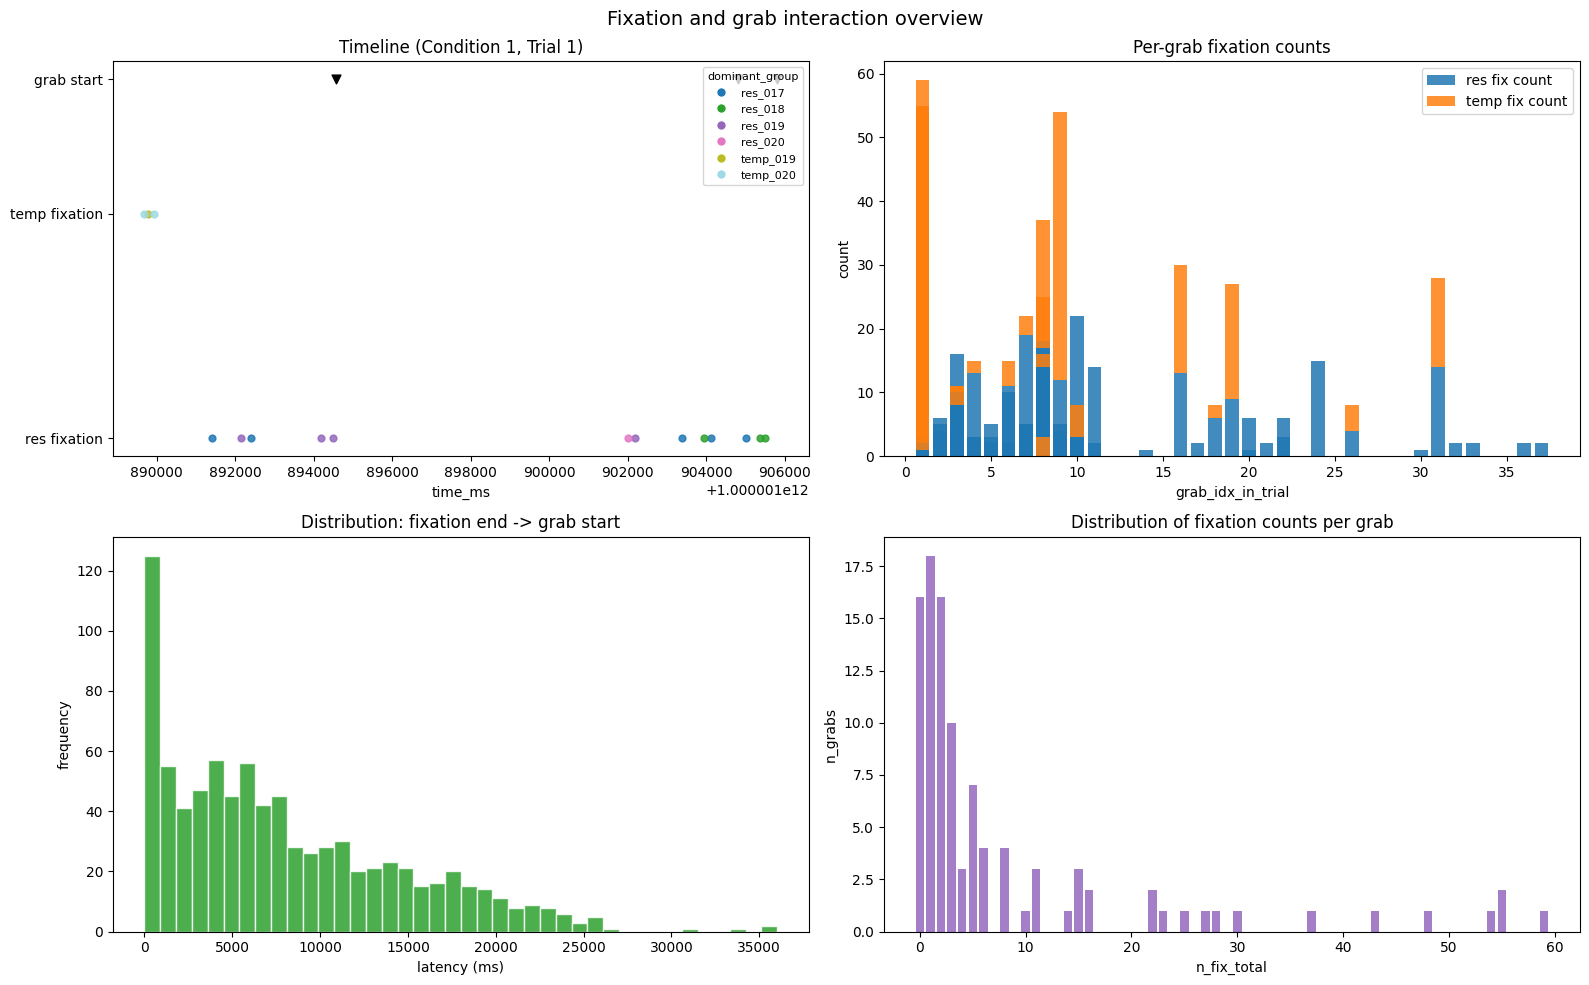

,condition_number,trial_number,grab_idx_in_trial,grabbed_name,n_fix_res,n_fix_temp,n_fix_total
0,1,1,1,brick_2x2_blue_dis_009,5.0,3.0,8.0
1,1,1,9,brick_2x2_green_res_018,5.0,0.0,5.0
2,1,1,10,brick_2x2_pink_res_017,3.0,0.0,3.0
3,1,2,2,brick_2x2_green_res_005,5.0,0.0,5.0
4,1,2,4,brick_2x2_yellow_dis_004,1.0,0.0,1.0
5,1,2,5,brick_2x2_yellow_dis_004,1.0,0.0,1.0
6,1,2,6,brick_2x2_pink_res_007,2.0,0.0,2.0
7,1,3,1,brick_2x4_green_res_067,3.0,3.0,6.0
8,1,3,2,brick_1x3_yellow_res_069,1.0,0.0,1.0
9,1,3,4,brick_2x4_blue_res_068,13.0,2.0,15.0


In [51]:
# --- Visualization: fixation-grab interaction across time ---
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if grab_fixation_summary_df.empty:
    print("No grab summary data available to plot.")
else:
    summary_plot = grab_fixation_summary_df.sort_values(
        ["condition_number", "trial_number", "grab_idx_in_trial"]
    ).reset_index(drop=True)

    events_plot = grab_fixation_events_df.copy()
    if not events_plot.empty:
        events_plot["fixation_to_grab_start_ms"] = (
            events_plot["curr_grab_start_time_ms"] - events_plot["fixation_end_time_ms"]
        )

    # Pick one trial for detailed timeline
    trial_key = (
        summary_plot[["condition_number", "trial_number"]]
        .drop_duplicates()
        .sort_values(["condition_number", "trial_number"])
        .iloc[0]
    )
    cond = trial_key["condition_number"]
    trial = trial_key["trial_number"]

    summary_trial = summary_plot[
        (summary_plot["condition_number"] == cond)
        & (summary_plot["trial_number"] == trial)
    ]
    events_trial = events_plot[
        (events_plot["condition_number"] == cond)
        & (events_plot["trial_number"] == trial)
    ] if not events_plot.empty else events_plot

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1) Timeline: fixation end times colored by dominant_group brick id + grab starts
    ax = axes[0, 0]
    if not events_trial.empty:
        y_map = {"res": 0, "temp": 1}

        groups = sorted(events_trial["dominant_group"].dropna().unique())
        cmap = plt.cm.get_cmap("tab20", max(len(groups), 1))
        color_map = {g: cmap(i) for i, g in enumerate(groups)}

        for g in groups:
            sub = events_trial[events_trial["dominant_group"] == g]
            ax.scatter(
                sub["fixation_end_time_ms"],
                sub["fixation_group_type"].map(y_map),
                c=[color_map[g]],
                s=24,
                alpha=0.85,
                label=g,
            )

        # Compact legend mapping color -> brick group
        handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[g], markersize=7, label=g)
            for g in groups
        ]

        # keep legend readable
        max_legend = 20
        if len(handles) > max_legend:
            handles = handles[:max_legend]
            handles.append(Line2D([0], [0], color="none", label=f"... +{len(groups)-max_legend} more"))
        ax.legend(handles=handles, title="dominant_group", loc="upper right", fontsize=8, title_fontsize=8)

    ax.scatter(
        summary_trial["curr_grab_start_time_ms"],
        [1.6] * len(summary_trial),
        c="black",
        marker="v",
        s=40,
        label="Grab start"
    )
    ax.set_title(f"Timeline (Condition {cond}, Trial {trial})")
    ax.set_xlabel("time_ms")
    ax.set_yticks([0, 1, 1.6])
    ax.set_yticklabels(["res fixation", "temp fixation", "grab start"])

    # 2) Per-grab fixation counts (res vs temp)
    ax = axes[0, 1]
    x = summary_plot["grab_idx_in_trial"].to_numpy()
    ax.bar(x, summary_plot["n_fix_res"], label="res fix count", color="tab:blue", alpha=0.85)
    ax.bar(x, summary_plot["n_fix_temp"], bottom=summary_plot["n_fix_res"], label="temp fix count", color="tab:orange", alpha=0.85)
    ax.set_title("Per-grab fixation counts")
    ax.set_xlabel("grab_idx_in_trial")
    ax.set_ylabel("count")
    ax.legend(loc="best")

    # 3) Distribution: fixation-to-grab latency
    ax = axes[1, 0]
    if not events_plot.empty:
        ax.hist(
            events_plot["fixation_to_grab_start_ms"].dropna(),
            bins=40,
            color="tab:green",
            alpha=0.85,
            edgecolor="white"
        )
        ax.set_title("Distribution: fixation end -> grab start")
        ax.set_xlabel("latency (ms)")
        ax.set_ylabel("frequency")
    else:
        ax.text(0.5, 0.5, "No event rows", ha="center", va="center")
        ax.set_axis_off()

    # 4) Distribution of fixation counts per grab
    ax = axes[1, 1]
    if summary_plot.empty:
        ax.text(0.5, 0.5, "No summary rows", ha="center", va="center")
        ax.set_axis_off()
    else:
        vc = summary_plot["n_fix_total"].value_counts().sort_index()
        ax.bar(vc.index.astype(float), vc.values, color="tab:purple", alpha=0.85)
        ax.set_title("Distribution of fixation counts per grab")
        ax.set_xlabel("n_fix_total")
        ax.set_ylabel("n_grabs")

    fig.suptitle("Fixation and grab interaction overview", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Compact table for quick interpretation
    display_cols = [
        "condition_number", "trial_number", "grab_idx_in_trial", "grabbed_name",
        "n_fix_res", "n_fix_temp", "n_fix_total"
    ]
    display(summary_plot[display_cols].head(20))

C:\Users\experiment\AppData\Local\Temp\ipykernel_15956\2641530959.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(object_names), 1))


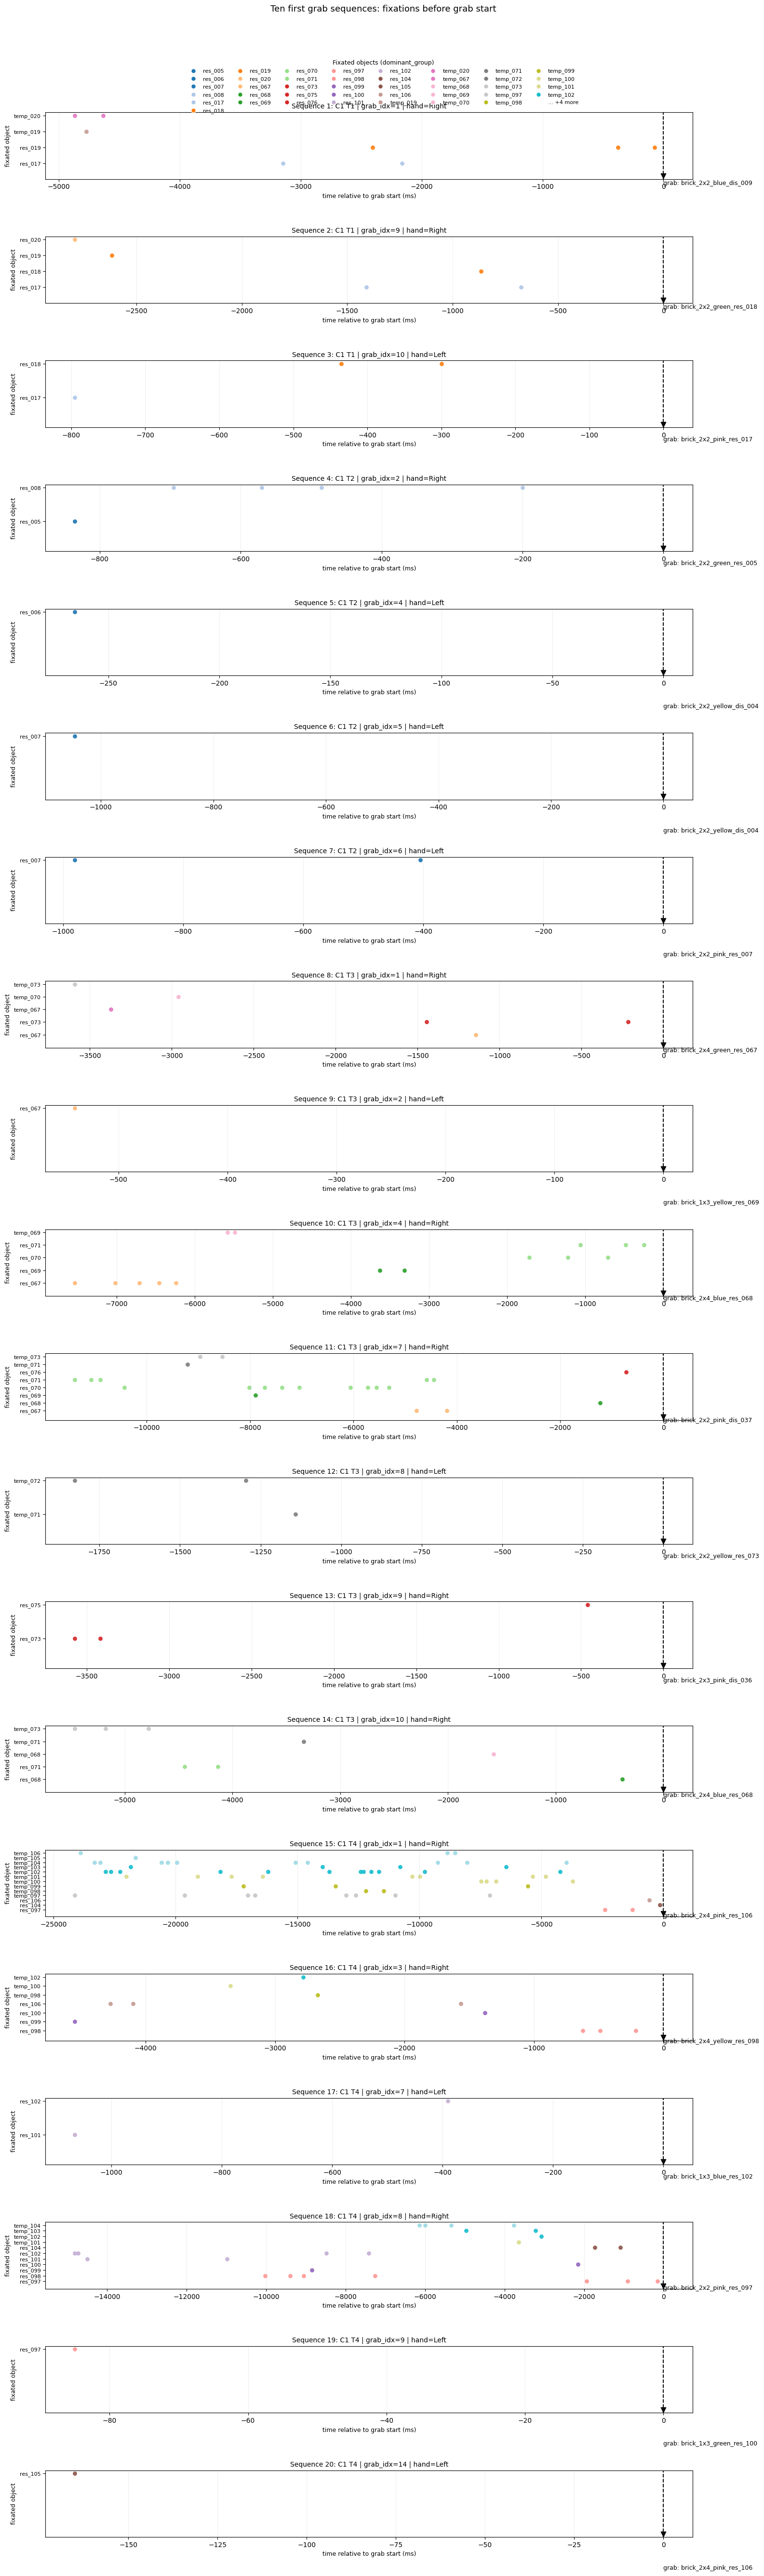

In [57]:
# --- 10 timeline plots: fixation objects before each grab ---
import matplotlib.pyplot as plt

if grab_fixation_summary_df.empty or grab_fixation_events_df.empty:
    print("No grab/fixation data available for 10-sequence timeline plots.")
else:
    key_cols = ["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"]

    # Pick the first 10 grabs in strict chronological order and label them 1..10
    seq_base = (
        grab_fixation_summary_df[grab_fixation_summary_df["n_fix_total"] > 0]
        .sort_values(["curr_grab_start_time_ms", "condition_number", "trial_number", "grab_idx_in_trial"])
        .head(20)
        .copy()
        .reset_index(drop=True)
    )
    seq_base["sequence_order"] = np.arange(1, len(seq_base) + 1)

    if seq_base.empty:
        print("No grabs with fixation events found.")
    else:
        # Build a color map for all objects present across these 10 sequences
        selected_keys = seq_base[key_cols].drop_duplicates()
        events_sel = grab_fixation_events_df.merge(selected_keys, on=key_cols, how="inner")

        object_names = sorted(events_sel["dominant_group"].dropna().unique())
        cmap = plt.cm.get_cmap("tab20", max(len(object_names), 1))
        color_map = {obj: cmap(i) for i, obj in enumerate(object_names)}

        n = len(seq_base)
        fig, axes = plt.subplots(n, 1, figsize=(16, 2.6 * n), sharex=False)
        if n == 1:
            axes = [axes]

        for ax, (_, seq) in zip(axes, seq_base.iterrows()):
            mask = (
                (grab_fixation_events_df["participant_id"] == seq["participant_id"])
                & (grab_fixation_events_df["condition_number"] == seq["condition_number"])
                & (grab_fixation_events_df["trial_number"] == seq["trial_number"])
                & (grab_fixation_events_df["grab_idx_in_trial"] == seq["grab_idx_in_trial"])
            )
            ev = grab_fixation_events_df[mask].copy()

            # Relative timeline in ms: 0 = grab start
            ev["t_rel_ms"] = ev["fixation_end_time_ms"] - seq["curr_grab_start_time_ms"]

            y_labels = sorted(ev["dominant_group"].dropna().unique())
            y_map = {name: i for i, name in enumerate(y_labels)}

            for name in y_labels:
                sub = ev[ev["dominant_group"] == name]
                ax.scatter(
                    sub["t_rel_ms"],
                    [y_map[name]] * len(sub),
                    color=color_map[name],
                    s=28,
                    alpha=0.9,
                    label=name,
                )

            # Mark grab start
            ax.axvline(0, color="black", linestyle="--", linewidth=1.4)
            ax.scatter([0], [-0.8], marker="v", color="black", s=55)
            ax.text(
                0,
                -1.25,
                f"grab: {seq['grabbed_name']}",
                fontsize=9,
                ha="left",
                va="center",
                color="black",
            )

            ax.set_yticks(range(len(y_labels)))
            ax.set_yticklabels(y_labels, fontsize=8)
            ax.set_ylabel("fixated object", fontsize=9)
            ax.set_xlabel("time relative to grab start (ms)", fontsize=9)
            ax.set_title(
                f"Sequence {int(seq['sequence_order'])}: "
                f"C{int(seq['condition_number'])} T{int(seq['trial_number'])} | "
                f"grab_idx={int(seq['grab_idx_in_trial'])} | hand={seq['hand']}",
                fontsize=10,
            )
            ax.grid(axis="x", alpha=0.2)

        # Global legend: all fixated objects shown in the 10 sequences
        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[obj], markersize=7, label=obj)
            for obj in object_names
        ]
        max_legend = 40
        if len(handles) > max_legend:
            handles = handles[:max_legend] + [plt.Line2D([0], [0], color="none", label=f"... +{len(object_names)-max_legend} more")]

        fig.legend(
            handles=handles,
            loc="upper center",
            ncol=8,
            fontsize=8,
            title="Fixated objects (dominant_group)",
            title_fontsize=9,
            frameon=False,
            bbox_to_anchor=(0.5, 1.01),
        )

        fig.suptitle("Ten first grab sequences: fixations before grab start", fontsize=13, y=1.03)
        plt.tight_layout()
        plt.show()

### ALL PARTICIPANTS

In [2]:
import pandas as pd
import numpy as np
import re
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

sns.set_style("whitegrid")

In [3]:
DATA_DIR = Path("../data/merged")         # synced csv files
EXCLUDE_PARTICIPANTS = {"036", "040"}  # update exclusions, maybe later 004?

DATA_DIR_DATA = Path("../data")           # other data files (excel etc.)
OUTPUT_DIR = Path("../data/df")           # processed outputs
OUTPUT_DIR.mkdir(exist_ok=True)           # create output folder if it doesn't exist

ANALYSIS_STREAMS = {
    "resource": ("Resource",),
    "building": ("Building",),
    "building_resource": ("Building", "Resource"),
}
STREAM_ORDER = list(ANALYSIS_STREAMS)

csv_files = sorted(DATA_DIR.glob("*_synced.csv"))

med_his_df = pd.read_excel(DATA_DIR_DATA / "medical_history_LegoVR_05_2026.xlsx")

In [4]:
# --- helper sets/dicts ---
UI_BUTTONS = {
    "ContinueButton", "NextItemButton", "RotationButton", "ValidationButtonLeft",
    "ValidationButtonRight", "QuestionButton1", "QuestionButton2", "QuestionButton3",
    "QuestionButton4", "QuestionButton5", "QuestionButton6", "QuestionButton7",
    "ImageFixationCross"
}
WORKSPACE = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}
LEGO_PREFABS = {
    "Lego_1x3_Green", "Lego_1x3_Pink", "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis", "Lego_2x2_Orange", "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue", "Lego_4x2_Green", "Lego_4x2_Green (1)",
    "Lego_4x2_Orange", "Lego_4x2_Pink_Dis"
}

# important defs
def get_object_group(name):
    if pd.isna(name): return np.nan
    name = str(name)
    if name == "model_desk_base": return "model_desk_base"
    if name == "resource_desk_base": return "resource_desk_base"
    if name == "work_desk_base": return "work_desk_base"
    m = re.search(r"_(res|temp|dis)_(\d+)", name)
    if m: return f"{m.group(1)}_{m.group(2)}"
    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name: return "board"
    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}: return "walls"
    if name in UI_BUTTONS: return "ui"
    if name in WORKSPACE: return "workspace"
    if name in DISPLAY_SURFACES: return "display_surface"
    if name in LEGO_PREFABS: return "lego_prefab"
    if name in ENVIRONMENT: return "environment"
    return f"unknown_{name}"

def is_brick_name(name):
    if pd.isna(name): return False
    return bool(re.match(r"^brick_.*_(res|temp|dis)_\d+$", str(name)))

def is_res_or_temp_group(group_name):
    if pd.isna(group_name): return False
    return bool(re.match(r"^(res|temp)_\d+$", str(group_name)))

def get_fixation_group_type(group_name):
    if pd.isna(group_name): return None
    m = re.match(r"^(res|temp)_\d+$", str(group_name))
    if not m: return None
    return m.group(1)

def _get_grab_pos_cols(hand):
    return (f"{hand}Grab_obj_pos_x", f"{hand}Grab_obj_pos_y", f"{hand}Grab_obj_pos_z")

def _infer_resource_bounds(df, pad=0.05):
    mask = (df["LeftFootArea"] == "Resource") | (df["RightFootArea"] == "Resource")
    samples = []
    for hand in ("Left", "Right"):
        x, y, z = _get_grab_pos_cols(hand)
        if all(c in df.columns for c in (x, y, z)):
            tmp = df.loc[mask, [x, y, z]].copy()
            tmp.columns = ["x", "y", "z"]
            samples.append(tmp)
    if not samples: return None
    pos = pd.concat(samples).dropna()
    if pos.empty: return None
    q_lo, q_hi = pos.quantile(0.05), pos.quantile(0.95)
    return {
        "x_min": q_lo["x"] - pad, "x_max": q_hi["x"] + pad,
        "y_min": q_lo["y"] - pad, "y_max": q_hi["y"] + pad,
        "z_min": q_lo["z"] - pad, "z_max": q_hi["z"] + pad,
    }

def classify_grab_start_area(left_foot_area, right_foot_area):
    areas = {left_foot_area, right_foot_area}
    if "Resource" in areas:
        return "Resource"
    if "Work" in areas or "Building" in areas:
        return "Building"
    return "Other"

def _prepare_sequence_frame(sync_df):
    df = sync_df.copy()
    required_cols = [
        "participant_id", "condition_number", "trial_number", "gaze_capture_time",
        "event_type", "hit_obj_name", "LeftHand_grabbed_name",
        "RightHand_grabbed_name", "LeftFootArea", "RightFootArea"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    df["gaze_capture_time"] = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
    df = df.dropna(subset=["gaze_capture_time"]).copy()
    df["time_ms"] = df["gaze_capture_time"] / 1e6
    df = df.sort_values(["participant_id", "condition_number", "trial_number", "gaze_capture_time"]).reset_index(drop=True)
    df["hit_obj_group"] = df["hit_obj_name"].apply(get_object_group)
    return df

def check_fixation_group_dominance(df, dominance_threshold=0.50, min_duration_ms=50, group_col="hit_obj_group"):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    df = df.copy().sort_values(block_cols + ["gaze_capture_time"])
    df["run_id"] = (
        (df["event_type"] != df["event_type"].shift())
        | (df["participant_id"] != df["participant_id"].shift())
        | (df["condition_number"] != df["condition_number"].shift())
        | (df["trial_number"] != df["trial_number"].shift())
    ).cumsum()
    results = []
    for run_id, grp in df[df["event_type"] == "fixation"].groupby("run_id", sort=True):
        start_time_ms = grp["time_ms"].min()
        end_time_ms = grp["time_ms"].max()
        duration_ms = end_time_ms - start_time_ms
        if duration_ms < min_duration_ms: continue
        looked_groups = grp[group_col].dropna()
        n_named = len(looked_groups)
        if n_named == 0:
            dominant_group, dominance, stable, n_unique_groups = None, np.nan, False, 0
        else:
            counts = looked_groups.value_counts()
            dominant_group = counts.index[0]
            dominance = counts.iloc[0] / n_named
            stable = dominance >= dominance_threshold
            n_unique_groups = looked_groups.nunique()
        results.append({
            "run_id": run_id,
            "participant_id": grp["participant_id"].iloc[0],
            "condition_number": grp["condition_number"].iloc[0],
            "trial_number": grp["trial_number"].iloc[0],
            "start_time_ms": start_time_ms,
            "end_time_ms": end_time_ms,
            "duration_ms": duration_ms,
            "n_samples": len(grp),
            "dominant_group": dominant_group,
            "dominance_ratio": dominance,
            "n_unique_groups": n_unique_groups,
            "stable": stable,
        })
    return pd.DataFrame(results)

def detect_grab_events(df):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    events = []
    for _, grp in df.groupby(block_cols, sort=True, dropna=False):
        grp = grp.sort_values("gaze_capture_time").copy()
        left_foot = grp["LeftFootArea"].to_numpy()
        right_foot = grp["RightFootArea"].to_numpy()
        for hand in ("Left", "Right"):
            grab_col = f"{hand}Hand_grabbed_name"
            x_col, y_col, z_col = _get_grab_pos_cols(hand)
            has_pos = all(c in grp.columns for c in (x_col, y_col, z_col))
            values = grp[grab_col].astype(object).to_numpy()
            times_ms = grp["time_ms"].to_numpy()
            times_ns = grp["gaze_capture_time"].to_numpy()
            pos_x = grp[x_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_y = grp[y_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_z = grp[z_col].to_numpy() if has_pos else np.full(len(grp), np.nan)
            i = 0
            while i < len(grp):
                name = values[i]
                if not is_brick_name(name):
                    i += 1
                    continue
                start_i = i
                while i + 1 < len(grp) and values[i + 1] == name:
                    i += 1
                end_i = i
                events.append({
                    "participant_id": grp["participant_id"].iloc[0],
                    "condition_number": grp["condition_number"].iloc[0],
                    "trial_number": grp["trial_number"].iloc[0],
                    "hand": hand,
                    "grabbed_name": name,
                    "grab_start_time_ms": times_ms[start_i],
                    "grab_start_time_ns": times_ns[start_i],
                    "grab_end_time_ms": times_ms[end_i],
                    "grab_end_time_ns": times_ns[end_i],
                    "grab_start_pos_x": pos_x[start_i],
                    "grab_start_pos_y": pos_y[start_i],
                    "grab_start_pos_z": pos_z[start_i],
                    "grab_start_area": classify_grab_start_area(left_foot[start_i], right_foot[start_i]),
                    "start_row_idx": int(start_i),
                    "end_row_idx": int(end_i),
                })
                i += 1
    if not events:
        return pd.DataFrame(columns=[
            "participant_id", "condition_number", "trial_number", "hand", "grabbed_name",
            "grab_start_time_ms", "grab_start_time_ns", "grab_end_time_ms", "grab_end_time_ns",
            "grab_start_pos_x", "grab_start_pos_y", "grab_start_pos_z",
            "start_row_idx", "end_row_idx", "grab_start_area",
            "grab_idx_in_trial", "prev_grab_start_time_ms", "prev_grab_start_time_ns"
        ])
    out = pd.DataFrame(events).sort_values(
        ["participant_id", "condition_number", "trial_number", "grab_start_time_ns"]
    ).reset_index(drop=True)
    out["grab_idx_in_trial"] = out.groupby(block_cols).cumcount() + 1
    out["prev_grab_start_time_ms"] = out.groupby(block_cols)["grab_start_time_ms"].shift(1)
    out["prev_grab_start_time_ns"] = out.groupby(block_cols)["grab_start_time_ns"].shift(1)
    return out

def build_grab_fixation_outputs(sync_df, dominance_threshold=0.50, min_duration_ms=50, area_filter=("Resource",)):
    df = _prepare_sequence_frame(sync_df)
    fixation_runs = check_fixation_group_dominance(df, dominance_threshold=dominance_threshold, min_duration_ms=min_duration_ms)
    fixation_candidates = fixation_runs[
        fixation_runs["stable"] & fixation_runs["dominant_group"].apply(is_res_or_temp_group)
    ].copy()
    fixation_candidates["fixation_group_type"] = fixation_candidates["dominant_group"].apply(get_fixation_group_type)
    all_grab_episodes = detect_grab_events(df)
    if area_filter is None:
        grab_events = all_grab_episodes.copy()
    else:
        grab_events = all_grab_episodes[all_grab_episodes["grab_start_area"].isin(area_filter)].copy()
    events_out = []
    for _, grab in grab_events.iterrows():
        key = (grab["participant_id"], grab["condition_number"], grab["trial_number"])
        block_fix = fixation_candidates[
            (fixation_candidates["participant_id"] == key[0])
            & (fixation_candidates["condition_number"] == key[1])
            & (fixation_candidates["trial_number"] == key[2])
        ]
        curr_t = grab["grab_start_time_ms"]
        prev_t = grab["prev_grab_start_time_ms"]
        if pd.isna(prev_t):
            in_window = block_fix["end_time_ms"] <= curr_t
        else:
            in_window = (block_fix["end_time_ms"] > prev_t) & (block_fix["end_time_ms"] <= curr_t)
        for _, fx in block_fix[in_window].iterrows():
            events_out.append({
                "participant_id": grab["participant_id"],
                "condition_number": grab["condition_number"],
                "trial_number": grab["trial_number"],
                "grab_idx_in_trial": grab["grab_idx_in_trial"],
                "hand": grab["hand"],
                "grabbed_name": grab["grabbed_name"],
                "grab_start_area": grab["grab_start_area"],
                "grab_start_pos_x": grab["grab_start_pos_x"],
                "grab_start_pos_y": grab["grab_start_pos_y"],
                "grab_start_pos_z": grab["grab_start_pos_z"],
                "prev_grab_start_time_ms": prev_t,
                "curr_grab_start_time_ms": curr_t,
                "grab_end_time_ms": grab["grab_end_time_ms"],
                "run_id": fx["run_id"],
                "fixation_start_time_ms": fx["start_time_ms"],
                "fixation_end_time_ms": fx["end_time_ms"],
                "fixation_duration_ms": fx["duration_ms"],
                "dominant_group": fx["dominant_group"],
                "fixation_group_type": fx["fixation_group_type"],
                "dominance_ratio": fx["dominance_ratio"],
                "n_samples": fx["n_samples"],
            })
    grab_fixation_events_df = pd.DataFrame(events_out)
    summary_base = grab_events[[
        "participant_id", "condition_number", "trial_number", "grab_idx_in_trial",
        "hand", "grabbed_name", "grab_start_area",
        "grab_start_pos_x", "grab_start_pos_y", "grab_start_pos_z",
        "prev_grab_start_time_ms", "grab_start_time_ms", "grab_end_time_ms"
    ]].rename(columns={"grab_start_time_ms": "curr_grab_start_time_ms"}).copy()
    if grab_fixation_events_df.empty:
        grab_fixation_summary_df = summary_base.copy()
        for col, default in [("n_fix_res", 0), ("n_fix_temp", 0), ("n_fix_total", 0),
                              ("dur_fix_res_ms", 0.0), ("dur_fix_temp_ms", 0.0),
                              ("dur_fix_total_ms", 0.0), ("res_share", np.nan), ("temp_share", np.nan)]:
            grab_fixation_summary_df[col] = default
    else:
        key_cols = ["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"]
        counts = (
            grab_fixation_events_df
            .pivot_table(index=key_cols, columns="fixation_group_type", values="run_id", aggfunc="count", fill_value=0)
            .rename(columns={"res": "n_fix_res", "temp": "n_fix_temp"})
            .reset_index()
        )
        durs = (
            grab_fixation_events_df
            .pivot_table(index=key_cols, columns="fixation_group_type", values="fixation_duration_ms", aggfunc="sum", fill_value=0.0)
            .rename(columns={"res": "dur_fix_res_ms", "temp": "dur_fix_temp_ms"})
            .reset_index()
        )
        grab_fixation_summary_df = summary_base.merge(counts, on=key_cols, how="left").merge(durs, on=key_cols, how="left")
        for col, default in [("n_fix_res", 0), ("n_fix_temp", 0), ("dur_fix_res_ms", 0.0), ("dur_fix_temp_ms", 0.0)]:
            if col not in grab_fixation_summary_df.columns:
                grab_fixation_summary_df[col] = default
            else:
                grab_fixation_summary_df[col] = grab_fixation_summary_df[col].fillna(default)
        grab_fixation_summary_df["n_fix_total"] = grab_fixation_summary_df["n_fix_res"] + grab_fixation_summary_df["n_fix_temp"]
        grab_fixation_summary_df["dur_fix_total_ms"] = grab_fixation_summary_df["dur_fix_res_ms"] + grab_fixation_summary_df["dur_fix_temp_ms"]
        dur_total = grab_fixation_summary_df["dur_fix_total_ms"].replace(0, np.nan)
        grab_fixation_summary_df["res_share"] = grab_fixation_summary_df["dur_fix_res_ms"] / dur_total
        grab_fixation_summary_df["temp_share"] = grab_fixation_summary_df["dur_fix_temp_ms"] / dur_total
    qc = {
        "n_rows": len(df),
        "n_fixation_runs": len(fixation_runs),
        "n_fixation_candidates_res_temp": len(fixation_candidates),
        "n_grab_episodes_all": len(all_grab_episodes),
        "n_grab_episodes_selected_area": len(grab_events),
        "selected_area_filter": "all" if area_filter is None else "+".join(area_filter),
        "n_grabs_with_fixations": int((grab_fixation_summary_df["n_fix_total"] > 0).sum()) if not grab_fixation_summary_df.empty else 0,
        "n_grabs_without_fixations": int((grab_fixation_summary_df["n_fix_total"] == 0).sum()) if not grab_fixation_summary_df.empty else 0,
        "n_event_rows": len(grab_fixation_events_df),
    }
    return {
        "prepared_df": df,
        "fixation_runs": fixation_runs,
        "fixation_candidates": fixation_candidates,
        "all_grab_episodes": all_grab_episodes,
        "grab_events": grab_events,
        "grab_fixation_events_df": grab_fixation_events_df,
        "grab_fixation_summary_df": grab_fixation_summary_df,
        "qc": qc,
    }

In [5]:
all_events = []
all_summary = []
all_qc = []
all_stats = {}
model_names = []

for file_path in csv_files:
    pid = file_path.stem.replace("_synced", "")
    if pid in EXCLUDE_PARTICIPANTS:
        continue

    print(f"Processing {pid}...")
    sync_df = pd.read_csv(file_path, low_memory=False)

    # descriptive stats for the raw synced file
    all_stats[pid] = sync_df.describe()

    # extract one model_name per participant/condition/trial
    trial_models = (
        sync_df[["participant_id", "condition_number", "trial_number", "model_name"]]
        .dropna(subset=["model_name"])
        .groupby(["participant_id", "condition_number", "trial_number"])["model_name"]
        .first()
        .reset_index()
    )
    model_names.append(trial_models)

    # main analysis: run the same extraction for each grab-area stream
    for stream_name, area_filter in ANALYSIS_STREAMS.items():
        out = build_grab_fixation_outputs(
            sync_df,
            dominance_threshold=0.50,
            min_duration_ms=50,
            area_filter=area_filter,
        )

        if not out["grab_fixation_events_df"].empty:
            events = out["grab_fixation_events_df"].copy()
            events["analysis_stream"] = stream_name
            events["source_file"] = file_path.name
            all_events.append(events)

        if not out["grab_fixation_summary_df"].empty:
            summary = out["grab_fixation_summary_df"].copy()
            summary["analysis_stream"] = stream_name
            summary["source_file"] = file_path.name
            all_summary.append(summary)

        qc_row = out["qc"].copy()
        qc_row["pid"] = pid
        qc_row["analysis_stream"] = stream_name
        qc_row["source_file"] = file_path.name
        all_qc.append(qc_row)

    del sync_df

# combine results
events_all = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
summary_all = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
qc_all = pd.DataFrame(all_qc)
overall_stats = pd.concat(all_stats.values()).groupby(level=0).mean() if all_stats else pd.DataFrame()

# combine model names
model_name_df = pd.concat(model_names, ignore_index=True) if model_names else pd.DataFrame()
model_name_df["participant_id"] = model_name_df["participant_id"].astype(str).str.zfill(3)
model_name_df["model_complexity"] = model_name_df["model_name"].str.extract(r"^(C[123])")

print("Done!")
print(model_name_df["model_name"].value_counts(dropna=False))
if not events_all.empty:
    print("\nGrab events by stream and area:")
    print(events_all.groupby(["analysis_stream", "grab_start_area"]).size())

Processing 001...
Processing 002...
Processing 003...
Processing 004...
Processing 005...
Processing 006...
Processing 007...
Processing 008...
Processing 009...
Processing 010...
Processing 011...
Processing 012...
Processing 013...
Processing 014...
Processing 015...
Processing 016...
Processing 017...
Processing 018...
Processing 019...
Processing 020...
Processing 021...
Processing 022...
Processing 023...
Processing 024...
Processing 025...
Processing 026...
Processing 027...
Processing 028...
Processing 029...
Processing 030...
Processing 031...
Processing 032...
Processing 033...
Processing 034...
Processing 035...
Processing 037...
Processing 038...
Processing 039...
Processing 041...
Processing 042...
Processing 043...
Processing 044...
Processing 045...
Processing 046...
Processing 047...
Processing 048...
Processing 049...
Processing 050...
Processing 051...
Done!
model_name
TM       194
C1M2A     49
C2M1F     49
C2M3F     48
C1M6A     48
C3M2A     48
C3M3F     48
C2M2A     

In [6]:
# Save outputs for all participants dfs in data folder

events_all.to_csv(OUTPUT_DIR / "grab_fixation_events_all.csv", index=False)
summary_all.to_csv(OUTPUT_DIR / "grab_fixation_summary_all.csv", index=False)
qc_all.to_csv(OUTPUT_DIR / "qc_all.csv", index=False)
overall_stats.to_csv(OUTPUT_DIR / "overall_stats.csv")
model_name_df.to_csv(OUTPUT_DIR / "model_name_df.csv", index=False)

# per participant stats in one Excel file
with pd.ExcelWriter(OUTPUT_DIR / "per_participant_stats.xlsx") as writer:
    overall_stats.to_excel(writer, sheet_name="overall")
    for pid, stats in all_stats.items():
        stats.to_excel(writer, sheet_name=pid[:31])

print("Saved!")

Saved!


In [7]:
#Load created files from data folder

# load processed outputs
events_all = pd.read_csv(OUTPUT_DIR / "grab_fixation_events_all.csv")
summary_all = pd.read_csv(OUTPUT_DIR / "grab_fixation_summary_all.csv")
qc_all = pd.read_csv(OUTPUT_DIR / "qc_all.csv")
overall_stats = pd.read_csv(OUTPUT_DIR / "overall_stats.csv", index_col=0)
model_name_df = pd.read_csv(OUTPUT_DIR / "model_name_df.csv")

# reload handedness from source
med_his_df = pd.read_excel(DATA_DIR_DATA / "medical_history_LegoVR_05_2026.xlsx")
med_his_df["participant_id"] = med_his_df["participant_id"].astype(str).str.zfill(3)
handedness_df = (
    med_his_df[~med_his_df["participant_id"].isin(EXCLUDE_PARTICIPANTS)]
    [["participant_id", "handedness"]]
    .dropna(subset=["handedness"])
)

In [8]:
df_sample = pd.read_csv(csv_files[0], low_memory=False)
print(df_sample["model_name"].value_counts(dropna=False))
print(df_sample[["condition_number", "trial_number", "model_name"]].drop_duplicates().head(20))

model_name
NaN      167029
TM       125553
C3M5F     42947
C3M2A     37959
C3M3F     37625
C3M6A     31926
C3M1F     29675
C2M2A     29121
C3M4A     23014
C2M3F     22404
C2M4A     19533
C2M5F     14376
C2M1F     13546
C1M4A     10008
C2M6A      8968
C1M3F      7649
C1M6A      7340
C1M2A      6990
C1M5F      6820
C1M1F      4481
Name: count, dtype: int64
        condition_number  trial_number model_name
0                      0             0        NaN
4662                   0             0         TM
93486                  1             0        NaN
96261                  1             0         TM
107098                 1             1        NaN
119578                 1             1      C1M5F
126398                 1             2        NaN
132115                 1             2      C1M2A
139105                 1             3        NaN
145587                 1             3      C3M1F
175262                 1             4        NaN
183438                 1             4     

In [9]:
print(summary_all.columns.tolist())
print(events_all.columns.tolist())

['participant_id', 'condition_number', 'trial_number', 'grab_idx_in_trial', 'hand', 'grabbed_name', 'grab_start_area', 'grab_start_pos_x', 'grab_start_pos_y', 'grab_start_pos_z', 'prev_grab_start_time_ms', 'curr_grab_start_time_ms', 'grab_end_time_ms', 'n_fix_res', 'n_fix_temp', 'dur_fix_res_ms', 'dur_fix_temp_ms', 'n_fix_total', 'dur_fix_total_ms', 'res_share', 'temp_share', 'analysis_stream', 'source_file']
['participant_id', 'condition_number', 'trial_number', 'grab_idx_in_trial', 'hand', 'grabbed_name', 'grab_start_area', 'grab_start_pos_x', 'grab_start_pos_y', 'grab_start_pos_z', 'prev_grab_start_time_ms', 'curr_grab_start_time_ms', 'grab_end_time_ms', 'run_id', 'fixation_start_time_ms', 'fixation_end_time_ms', 'fixation_duration_ms', 'dominant_group', 'fixation_group_type', 'dominance_ratio', 'n_samples', 'analysis_stream', 'source_file']


In [10]:
print(events_all["trial_number"].unique())
print(summary_all["trial_number"].unique())

[1 2 3 4 5 6]
[1 2 3 4 5 6]


In [11]:
#no trial 0?!
print(events_all[events_all["trial_number"] == 0].shape)
print(summary_all[summary_all["trial_number"] == 0].shape)

(0, 23)
(0, 23)


In [12]:
summary_all.groupby("participant_id")["res_share"].mean()

participant_id
1     0.896056
2     0.853182
3     0.868122
4     0.673523
5     0.854029
6     0.854715
7     0.876052
8     0.805539
9     0.854928
10    0.855809
11    0.786913
12    0.836738
13    0.873318
14    0.700400
15    0.836574
16    0.870016
17    0.863834
18    0.810185
19    0.841881
20    0.777716
21    0.840453
22    0.829179
23    0.877703
24    0.829386
25    0.822701
26    0.835357
27    0.808822
28    0.883553
29    0.802074
30    0.800832
31    0.747914
32    0.807094
33    0.880541
34    0.793809
35    0.803772
37    0.847569
38    0.850125
39    0.781956
41    0.914573
42    0.833555
43    0.884888
44    0.797072
45    0.883824
46    0.799203
47    0.891689
48    0.838027
49    0.799432
50    0.842406
51    0.809084
Name: res_share, dtype: float64

In [13]:
print(med_his_df.shape)
print(med_his_df.head())
print(med_his_df.columns.tolist())

(75, 38)
  participant_id sheet_language  consciousness_disorders  seizures  \
0            001        english                      0.0       0.0   
1            002        english                      0.0       0.0   
2            003        english                      0.0       0.0   
3            004        deutsch                      0.0       0.0   
4            005        deutsch                      0.0       0.0   

   dizziness_vertigo  seasickness  tinnitus      headache migraine  tremor  \
0                0.0          0.0       0.0  occasionally       no     0.0   
1                0.0          1.0       0.0  occasionally       no     0.0   
2                0.0          0.0       0.0  occasionally       no     0.0   
3                0.0          0.0       0.0            no       no     0.0   
4                0.0          0.0       0.0            no       no     0.0   

   ...  other_eye_problems  which_other_eye_problems  handedness  muscle_pain  \
0  ...              

In [14]:
# --- Merge metadata, apply shared exclusions, and define analysis helpers ---

# Load the processed outputs if this notebook was reopened after saving.
events_all = pd.read_csv(OUTPUT_DIR / "grab_fixation_events_all.csv")
summary_all = pd.read_csv(OUTPUT_DIR / "grab_fixation_summary_all.csv")
qc_all = pd.read_csv(OUTPUT_DIR / "qc_all.csv")
overall_stats = pd.read_csv(OUTPUT_DIR / "overall_stats.csv", index_col=0)
model_name_df = pd.read_csv(OUTPUT_DIR / "model_name_df.csv")
med_his_df = pd.read_excel(DATA_DIR_DATA / "medical_history_LegoVR_05_2026.xlsx")

for frame in (events_all, summary_all, model_name_df, med_his_df):
    frame["participant_id"] = frame["participant_id"].astype(str).str.zfill(3)

handedness_df = (
    med_his_df[~med_his_df["participant_id"].isin(EXCLUDE_PARTICIPANTS)]
    [["participant_id", "handedness"]]
    .dropna(subset=["handedness"])
    .drop_duplicates("participant_id")
)

model_name_df = model_name_df.drop_duplicates(["participant_id", "condition_number", "trial_number"])
if "model_complexity" not in model_name_df.columns:
    model_name_df["model_complexity"] = model_name_df["model_name"].str.extract(r"^(C[123])")

merge_keys = ["participant_id", "condition_number", "trial_number"]
events_all = events_all.merge(handedness_df, on="participant_id", how="left")
summary_all = summary_all.merge(handedness_df, on="participant_id", how="left")
events_all = events_all.merge(model_name_df, on=merge_keys, how="left")
summary_all = summary_all.merge(model_name_df, on=merge_keys, how="left")

events_all["model_complexity"] = events_all["model_name"].str.extract(r"^(C[123])")
summary_all["model_complexity"] = summary_all["model_name"].str.extract(r"^(C[123])")

for frame in (events_all, summary_all):
    frame["condition_number"] = frame["condition_number"].astype(str)

VALID_MODEL_MASK = lambda frame: (
    frame["model_name"].notna()
    & ~frame["model_name"].isin(["TM", "None"])
    & frame["model_complexity"].notna()
    & frame["handedness"].notna()
)

events_analysis = events_all[VALID_MODEL_MASK(events_all)].copy()
summary_analysis = summary_all[VALID_MODEL_MASK(summary_all)].copy()

COMPLEXITY_ORDER = ["C1", "C2", "C3"]
CONDITION_ORDER = sorted(events_analysis["condition_number"].dropna().unique(), key=lambda x: int(float(x)))

print("Handedness counts:")
print(handedness_df["handedness"].value_counts())
print("\nRows after excluding TM, None, missing complexity, and missing handedness:")
print(f"events_analysis: {len(events_analysis)} / {len(events_all)}")
print(f"summary_analysis: {len(summary_analysis)} / {len(summary_all)}")
print("\nEvent rows by stream:")
print(events_analysis["analysis_stream"].value_counts())


def build_dominant_ratio_table(events, group_cols):
    counts = (
        events.groupby(group_cols + ["hand"])
        .size()
        .reset_index(name="grab_count")
        .pivot_table(
            index=group_cols,
            columns="hand",
            values="grab_count",
            fill_value=0,
        )
        .rename(columns={"Left": "left_grabs", "Right": "right_grabs"})
        .reset_index()
    )

    for col in ["left_grabs", "right_grabs"]:
        if col not in counts.columns:
            counts[col] = 0

    counts["dominant_grabs"] = np.where(
        counts["handedness"].eq("right"),
        counts["right_grabs"],
        counts["left_grabs"],
    )
    counts["nondominant_grabs"] = np.where(
        counts["handedness"].eq("right"),
        counts["left_grabs"],
        counts["right_grabs"],
    )
    counts["total_grabs"] = counts["dominant_grabs"] + counts["nondominant_grabs"]
    counts["dominant_ratio"] = counts["dominant_grabs"] / counts["total_grabs"].replace(0, np.nan)
    return counts.dropna(subset=["handedness", "dominant_ratio"])


def run_anova(data, formula):
    model = ols(formula, data=data).fit()
    return anova_lm(model, typ=2)


def describe_dominant_ratio(data, group_cols):
    return (
        data.groupby(group_cols)["dominant_ratio"]
        .agg(["mean", "std", "median", "count"])
        .round(3)
    )

Handedness counts:
handedness
right    43
left      6
Name: count, dtype: int64

Rows after excluding TM, None, missing complexity, and missing handedness:
events_analysis: 171228 / 175874
summary_analysis: 31378 / 31944

Event rows by stream:
analysis_stream
building_resource    85614
resource             53006
building             32608
Name: count, dtype: int64


In [20]:
# mean grabs per trial per complexity
grabs_per_trial = (
    summary_all.groupby(["model_complexity", "participant_id", "condition_number", "trial_number"])
    .size()
    .groupby("model_complexity")
    .mean()
    .round(2)
)
print(grabs_per_trial)

model_complexity
C1    17.97
C2    30.67
C3    62.11
dtype: float64


In [21]:
summary_all["model_complexity"] = summary_all["model_name"].str.extract(r"^(C[123])")
# gives C1, C2, C3 or NaN for TM

In [22]:
unmatched = summary_all[summary_all["handedness"].isna()]["participant_id"].unique()
print(f"Unmatched participant IDs: {unmatched}")
print(f"Participants in handedness_df: {handedness_df['participant_id'].unique()}")

Unmatched participant IDs: ['005']
Participants in handedness_df: ['001' '002' '003' '004' '006' '007' '008' '009' '010' '011' '012' '013'
 '014' '015' '016' '017' '018' '019' '020' '021' '022' '023' '024' '025'
 '026' '027' '028' '029' '030' '031' '032' '033' '034' '035' '037' '038'
 '039' '041' '042' '043' '044' '045' '046' '047' '048' '049' '050' '051'
 '0CN']


In [23]:
print(summary_all.columns.tolist())
print(events_all.columns.tolist())

['participant_id', 'condition_number', 'trial_number', 'grab_idx_in_trial', 'hand', 'grabbed_name', 'grab_start_area', 'grab_start_pos_x', 'grab_start_pos_y', 'grab_start_pos_z', 'prev_grab_start_time_ms', 'curr_grab_start_time_ms', 'grab_end_time_ms', 'n_fix_res', 'n_fix_temp', 'dur_fix_res_ms', 'dur_fix_temp_ms', 'n_fix_total', 'dur_fix_total_ms', 'res_share', 'temp_share', 'analysis_stream', 'source_file', 'handedness', 'model_name', 'model_complexity']
['participant_id', 'condition_number', 'trial_number', 'grab_idx_in_trial', 'hand', 'grabbed_name', 'grab_start_area', 'grab_start_pos_x', 'grab_start_pos_y', 'grab_start_pos_z', 'prev_grab_start_time_ms', 'curr_grab_start_time_ms', 'grab_end_time_ms', 'run_id', 'fixation_start_time_ms', 'fixation_end_time_ms', 'fixation_duration_ms', 'dominant_group', 'fixation_group_type', 'dominance_ratio', 'n_samples', 'analysis_stream', 'source_file', 'handedness', 'model_name', 'model_complexity']


In [24]:
events_all["participant_id"] = events_all["participant_id"].astype(str).str.zfill(3)
summary_all["participant_id"] = summary_all["participant_id"].astype(str).str.zfill(3)

events_all = events_all[~events_all["participant_id"].isin(EXCLUDE_PARTICIPANTS)]
summary_all = summary_all[~summary_all["participant_id"].isin(EXCLUDE_PARTICIPANTS)]

print("Remaining participants:", sorted(events_all["participant_id"].unique()))

Remaining participants: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '037', '038', '039', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051']



RESOURCE
Descriptives: model complexity x handedness


mean    std  median  count
model_complexity handedness                             
C1               left        0.488  0.208   0.420      6
                 right       0.458  0.189   0.382     42
C2               left        0.377  0.196   0.316      6
                 right       0.621  0.144   0.646     42
C3               left        0.478  0.221   0.497      6
                 right       0.569  0.130   0.558     41

Descriptives: condition x handedness


mean    std  median  count
condition_number handedness                             
1                left        0.379  0.164   0.393      6
                 right       0.600  0.160   0.607     42
2                left        0.419  0.234   0.389      6
                 right       0.571  0.129   0.592     41
3                left        0.523  0.225   0.592      6
                 right       0.561  0.171   0.566     41

Descriptives: condition x model complexity x handedness


mean    std  median  count
condition_number model_complexity handedness                             
1                C1               left        0.435  0.292   0.411      6
                                  right       0.537  0.237   0.514     42
                 C2               left        0.226  0.167   0.153      6
                                  right       0.658  0.183   0.674     42
                 C3               left        0.464  0.224   0.505      6
                                  right       0.569  0.188   0.558     41
2                C1               left        0.478  0.205   0.411      6
                                  right       0.421  0.253   0.391     41
                 C2               left        0.399  0.298   0.367      6
                                  right       0.597  0.171   0.642     41
                 C3               left        0.415  0.212   0.392      6
                                  right       0.580  0.172   0.567     41
3                C1               left        0.542  0.274   0.592      6
                                  right       0.377  0.254   0.318     41
                 C2               left        0.486  0.240   0.411      6
                                  right       0.602  0.211   0.618     41
                 C3               left        0.553  0.274   0.612      6
                                  right       0.558  0.198   0.573     41

/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_97750/2817625784.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


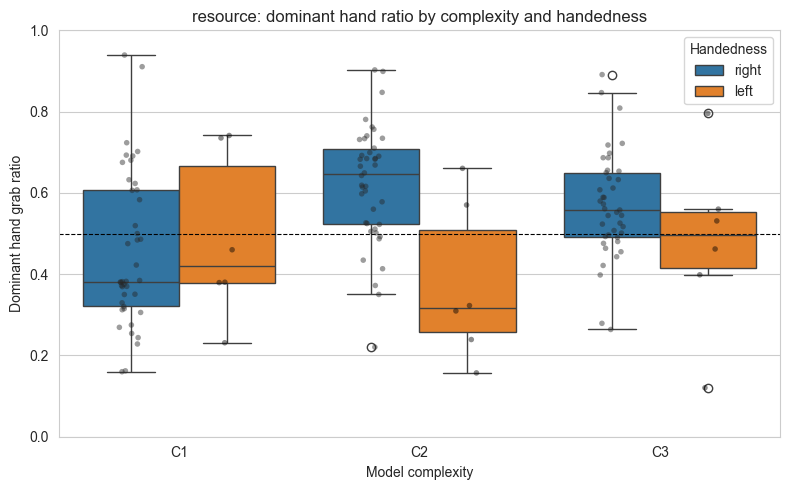

/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_97750/2817625784.py:81: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


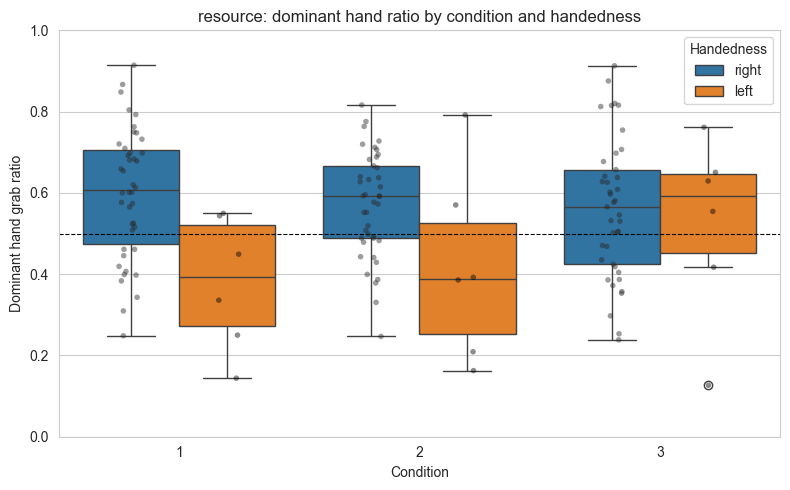

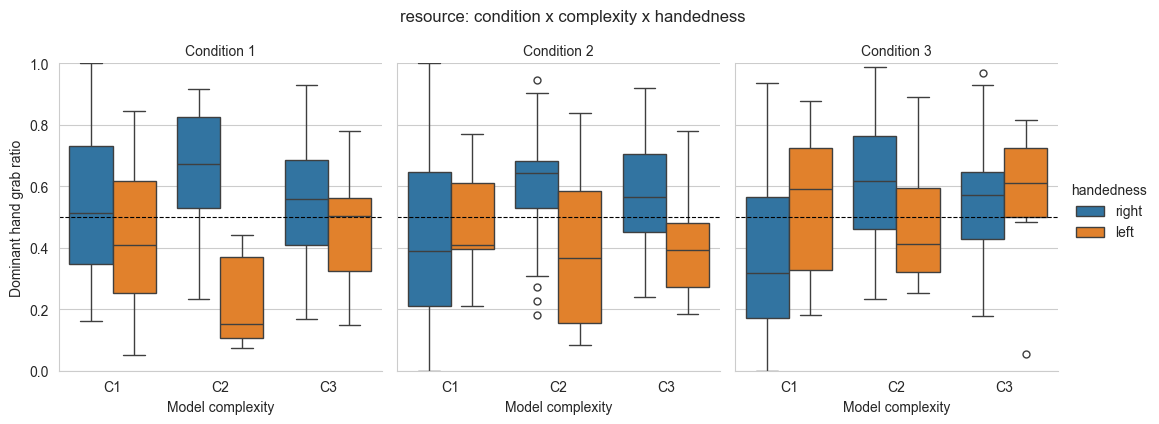

ANOVA: model complexity x handedness


,sum_sq,df,F,PR(>F)
C(model_complexity),0.431899,2.0,8.099956,0.000473
C(handedness),0.163461,1.0,6.131181,0.014500
C(model_complexity):C(handedness),0.199298,2.0,3.737685,0.026271
Residual,3.652503,137.0,NaN,NaN


ANOVA: condition x handedness


,sum_sq,df,F,PR(>F)
C(condition_number),0.010900,2.0,0.209249,0.811454
C(handedness),0.295295,1.0,11.337159,0.000988
C(condition_number):C(handedness),0.090058,2.0,1.728790,0.181377
Residual,3.542341,136.0,NaN,NaN


ANOVA: condition x handedness x model complexity


...

Descriptives: condition x handedness


mean    std  median  count
condition_number handedness                             
1                left        0.453  0.108   0.443      6
                 right       0.606  0.193   0.648     42
2                left        0.476  0.168   0.422      6
                 right       0.591  0.200   0.571     41
3                left        0.521  0.169   0.545      6
                 right       0.616  0.203   0.625     41

Descriptives: condition x model complexity x handedness


mean    std  median  count
condition_number model_complexity handedness                             
1                C1               left        0.531  0.387   0.597      6
                                  right       0.565  0.313   0.598     38
                 C2               left        0.330  0.196   0.269      6
                                  right       0.525  0.302   0.568     39
                 C3               left        0.455  0.133   0.443      6
                                  right       0.632  0.223   0.656     41
2                C1               left        0.669  0.398   0.778      6
                                  right       0.502  0.382   0.529     39
                 C2               left        0.340  0.247   0.257      6
                                  right       0.601  0.290   0.525     39
                 C3               left        0.519  0.210   0.416      6
                                  right       0.611  0.227   0.595     41
3                C1               left        0.584  0.287   0.543      6
                                  right       0.555  0.363   0.513     36
                 C2               left        0.472  0.366   0.552      6
                                  right       0.656  0.273   0.680     39
                 C3               left        0.523  0.175   0.529      6
                                  right       0.594  0.236   0.612     41

/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_97750/2817625784.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


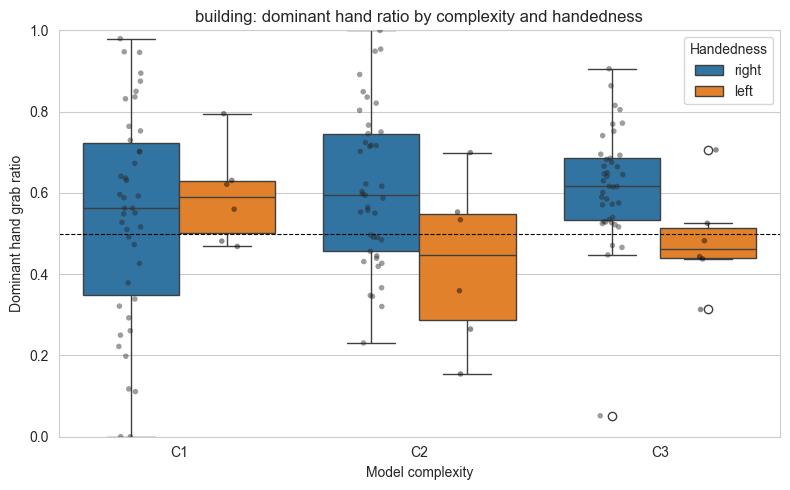

/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_97750/2817625784.py:81: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


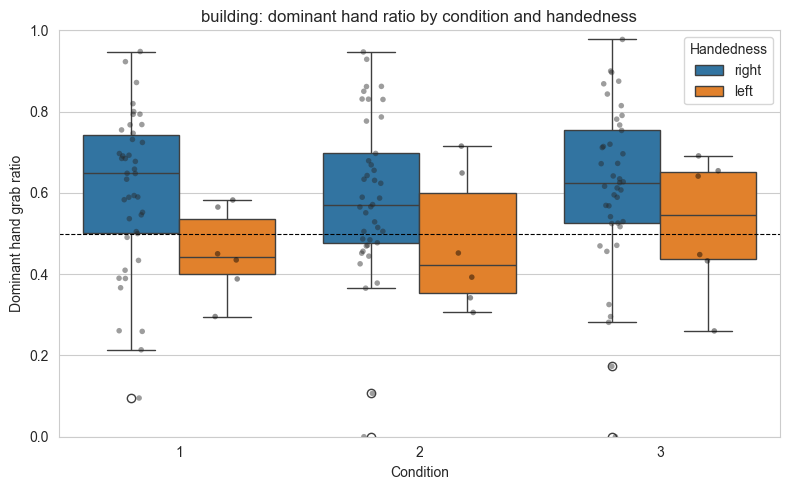

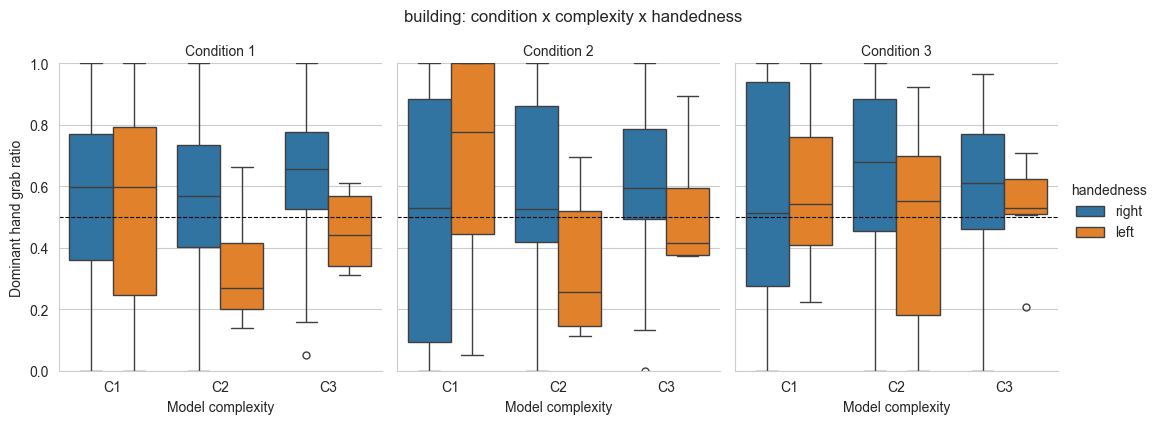

ANOVA: model complexity x handedness


,sum_sq,df,F,PR(>F)
C(model_complexity),0.069505,2.0,0.875250,0.419092
C(handedness),0.124431,1.0,3.133836,0.078924
C(model_complexity):C(handedness),0.156323,2.0,1.968527,0.143622
Residual,5.399955,136.0,NaN,NaN


ANOVA: condition x handedness


,sum_sq,df,F,PR(>F)
C(condition_number),0.017922,2.0,0.238270,0.788318
C(handedness),0.230319,1.0,6.123954,0.014566
C(condition_number):C(handedness),0.009383,2.0,0.124749,0.882819
Residual,5.114895,136.0,NaN,NaN


ANOVA: condition x handedness x model complexity


...

Descriptives: condition x handedness


mean    std  median  count
condition_number handedness                             
1                left        0.404  0.142   0.428      6
                 right       0.604  0.141   0.618     42
2                left        0.437  0.137   0.429      6
                 right       0.588  0.123   0.589     41
3                left        0.530  0.194   0.589      6
                 right       0.583  0.142   0.594     41

Descriptives: condition x model complexity x handedness


mean    std  median  count
condition_number model_complexity handedness                             
1                C1               left        0.518  0.226   0.416      6
                                  right       0.541  0.204   0.521     42
                 C2               left        0.267  0.144   0.254      6
                                  right       0.634  0.168   0.633     42
                 C3               left        0.464  0.160   0.500      6
                                  right       0.590  0.153   0.588     41
2                C1               left        0.523  0.141   0.494      6
                                  right       0.485  0.249   0.509     41
                 C2               left        0.400  0.192   0.328      6
                                  right       0.603  0.166   0.608     41
                 C3               left        0.437  0.134   0.444      6
                                  right       0.597  0.154   0.594     41
3                C1               left        0.552  0.219   0.558      6
                                  right       0.432  0.244   0.422     41
                 C2               left        0.512  0.221   0.484      6
                                  right       0.616  0.191   0.655     41
                 C3               left        0.540  0.226   0.599      6
                                  right       0.579  0.158   0.581     41

/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_97750/2817625784.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


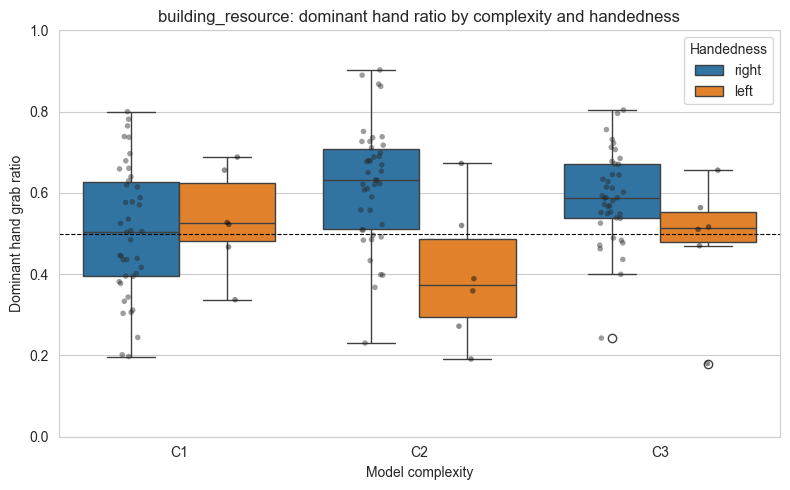

/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_97750/2817625784.py:81: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


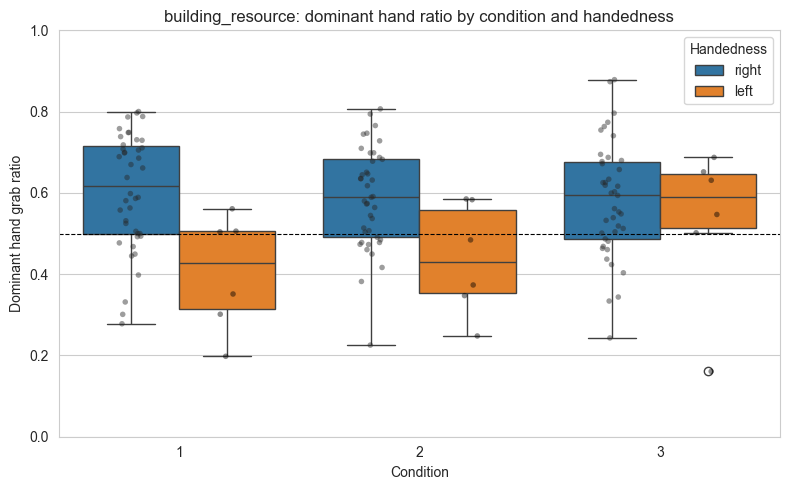

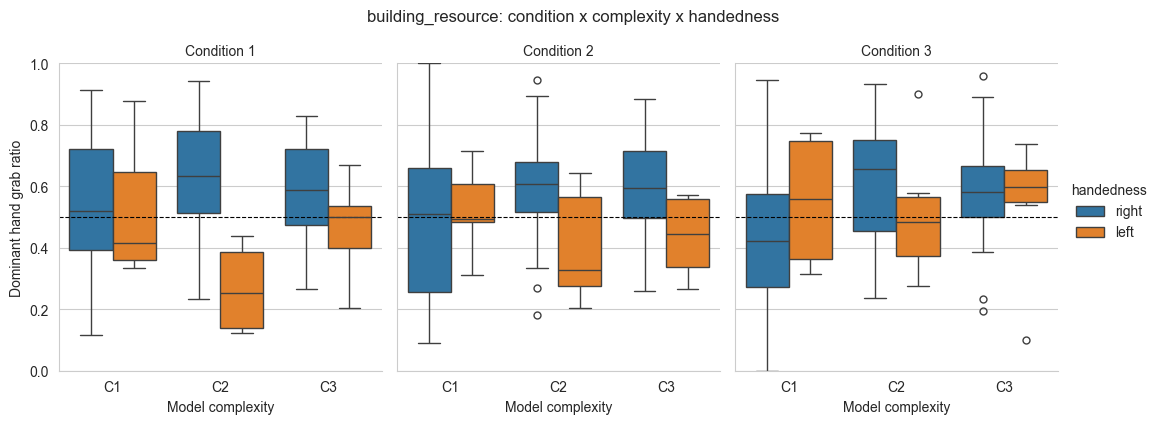

ANOVA: model complexity x handedness


,sum_sq,df,F,PR(>F)
C(model_complexity),0.196093,2.0,4.873200,0.009026
C(handedness),0.157909,1.0,7.848561,0.005823
C(model_complexity):C(handedness),0.162910,2.0,4.048556,0.019576
Residual,2.756373,137.0,NaN,NaN


ANOVA: condition x handedness


,sum_sq,df,F,PR(>F)
C(condition_number),0.002767,2.0,0.071867,0.930690
C(handedness),0.285340,1.0,14.824351,0.000181
C(condition_number):C(handedness),0.059598,2.0,1.548145,0.216366
Residual,2.617737,136.0,NaN,NaN


ANOVA: condition x handedness x model complexity


,sum_sq,df,F,PR(>F)
C(condition_number),0.049802,2.0,0.686900,0.503716
C(handedness),0.434173,1.0,11.976659,0.000596
C(model_complexity),0.782544,2.0,10.793239,0.000027
C(condition_number):C(handedness),0.216787,2.0,2.990033,0.051392
C(condition_number):C(model_complexity),0.163922,4.0,1.130450,0.341613
C(handedness):C(model_complexity),0.575159,2.0,7.932890,0.000417
C(condition_number):C(handedness):C(model_complexity),0.064000,4.0,0.441361,0.778706
Residual,14.754389,407.0,NaN,NaN


In [26]:
# --- Stream-wise descriptive statistics, visualizations, and ANOVAs ---

stream_results = {}

for stream_name in STREAM_ORDER:
    print(f"\n{'=' * 80}\n{stream_name.upper()}\n{'=' * 80}")

    stream_events = events_analysis[events_analysis["analysis_stream"] == stream_name].copy()
    if stream_events.empty:
        print("No analysis rows for this stream after exclusions.")
        continue

    grab_counts_complexity = build_dominant_ratio_table(
        stream_events,
        ["participant_id", "handedness", "model_complexity"],
    )
    grab_counts_condition = build_dominant_ratio_table(
        stream_events,
        ["participant_id", "handedness", "condition_number"],
    )
    grab_counts_full = build_dominant_ratio_table(
        stream_events,
        ["participant_id", "handedness", "condition_number", "model_complexity"],
    )

    stream_results[stream_name] = {
        "events": stream_events,
        "by_complexity": grab_counts_complexity,
        "by_condition": grab_counts_condition,
        "full": grab_counts_full,
    }

    print("Descriptives: model complexity x handedness")
    display(describe_dominant_ratio(grab_counts_complexity, ["model_complexity", "handedness"]))

    print("Descriptives: condition x handedness")
    display(describe_dominant_ratio(grab_counts_condition, ["condition_number", "handedness"]))

    print("Descriptives: condition x model complexity x handedness")
    display(describe_dominant_ratio(grab_counts_full, ["condition_number", "model_complexity", "handedness"]))

    # Visualization: complexity x handedness
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=grab_counts_complexity,
        x="model_complexity",
        y="dominant_ratio",
        hue="handedness",
        order=COMPLEXITY_ORDER,
    )
    sns.stripplot(
        data=grab_counts_complexity,
        x="model_complexity",
        y="dominant_ratio",
        hue="handedness",
        order=COMPLEXITY_ORDER,
        dodge=True,
        color="black",
        alpha=0.45,
        size=4,
        legend=False,
    )
    plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"{stream_name}: dominant hand ratio by complexity and handedness")
    plt.ylabel("Dominant hand grab ratio")
    plt.xlabel("Model complexity")
    plt.ylim(0, 1)
    plt.legend(title="Handedness")
    plt.tight_layout()
    plt.show()

    # Visualization: condition x handedness
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=grab_counts_condition,
        x="condition_number",
        y="dominant_ratio",
        hue="handedness",
        order=CONDITION_ORDER,
    )
    sns.stripplot(
        data=grab_counts_condition,
        x="condition_number",
        y="dominant_ratio",
        hue="handedness",
        order=CONDITION_ORDER,
        dodge=True,
        color="black",
        alpha=0.45,
        size=4,
        legend=False,
    )
    plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"{stream_name}: dominant hand ratio by condition and handedness")
    plt.ylabel("Dominant hand grab ratio")
    plt.xlabel("Condition")
    plt.ylim(0, 1)
    plt.legend(title="Handedness")
    plt.tight_layout()
    plt.show()

    # Visualization: condition x complexity x handedness
    g = sns.catplot(
        data=grab_counts_full,
        x="model_complexity",
        y="dominant_ratio",
        hue="handedness",
        col="condition_number",
        kind="box",
        order=COMPLEXITY_ORDER,
        col_order=CONDITION_ORDER,
        height=4,
        aspect=0.9,
        sharey=True,
    )
    g.set_axis_labels("Model complexity", "Dominant hand grab ratio")
    g.set_titles("Condition {col_name}")
    for ax in g.axes.flat:
        ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
        ax.set_ylim(0, 1)
    g.fig.suptitle(f"{stream_name}: condition x complexity x handedness", y=1.05)
    plt.show()

    print("ANOVA: model complexity x handedness")
    display(run_anova(
        grab_counts_complexity,
        "dominant_ratio ~ C(model_complexity) * C(handedness)",
    ))

    print("ANOVA: condition x handedness")
    display(run_anova(
        grab_counts_condition,
        "dominant_ratio ~ C(condition_number) * C(handedness)",
    ))

    print("ANOVA: condition x handedness x model complexity")
    display(run_anova(
        grab_counts_full,
        "dominant_ratio ~ C(condition_number) * C(handedness) * C(model_complexity)",
    ))

In [27]:
# get grab counts per participant and hand (for all models there are 126 model bricks in total)
grab_counts = (
    events_all.groupby(["participant_id", "hand"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"Left": "left_grabs", "Right": "right_grabs"})
    .reset_index()
)

# merge with handedness
grab_counts = grab_counts.merge(handedness_df, on="participant_id", how="left")

# add dominant vs non-dominant hand grab ratio
grab_counts["dominant_grabs"] = grab_counts.apply(
    lambda r: r["right_grabs"] if r["handedness"] == "right" else r["left_grabs"], axis=1
)
grab_counts["nondominant_grabs"] = grab_counts.apply(
    lambda r: r["left_grabs"] if r["handedness"] == "right" else r["right_grabs"], axis=1
)
grab_counts["dominant_ratio"] = grab_counts["dominant_grabs"] / (grab_counts["dominant_grabs"] + grab_counts["nondominant_grabs"])

print(grab_counts.head())
print(grab_counts["handedness"].value_counts())

  participant_id  left_grabs  right_grabs handedness  dominant_grabs  \
0            001        2104         3166      right            3166   
1            002        1204         2230      right            2230   
2            003        1168         1588      right            1588   
3            004          52          204      right             204   
4            005        1126         3520        NaN            1126   

   nondominant_grabs  dominant_ratio  
0               2104        0.600759  
1               1204        0.649388  
2               1168        0.576197  
3                 52        0.796875  
4               3520        0.242359  
handedness
right    42
left      6
Name: count, dtype: int64


In [116]:
# keep originals intact
events_excl = events_all[events_all["participant_id"] != "004"]
summary_excl = summary_all[summary_all["participant_id"] != "004"]
handedness_excl = handedness_df[handedness_df["participant_id"] != "004"]

In [ ]:
# recreate grab_counts_model without participant 004
grab_counts_model = (
    events_all.groupby(["participant_id", "model_complexity", "hand"])
    .size()
    .reset_index(name="grab_count")
    .pivot_table(
index=["participant_id", "model_complexity"],
columns="hand",
values="grab_count",
fill_value=0
    )
    .rename(columns={"Left": "left_grabs", "Right": "right_grabs"})
    .reset_index()
)
grab_counts_model = grab_counts_model.merge(handedness_df, on="participant_id", how="left")
grab_counts_model["dominant_grabs"] = grab_counts_model.apply(
lambda r: r["right_grabs"] if r["handedness"] == "right" else r["left_grabs"], axis=1
)
grab_counts_model["nondominant_grabs"] = grab_counts_model.apply(
lambda r: r["left_grabs"] if r["handedness"] == "right" else r["right_grabs"], axis=1
)
grab_counts_model["dominant_ratio"] = grab_counts_model["dominant_grabs"] / (
grab_counts_model["dominant_grabs"] + grab_counts_model["nondominant_grabs"]
)
print(grab_counts_model.head())
print(grab_counts_model.groupby(["handedness", "model_complexity"])[["left_grabs", "right_grabs", "dominant_ratio"]].mean().round(3))

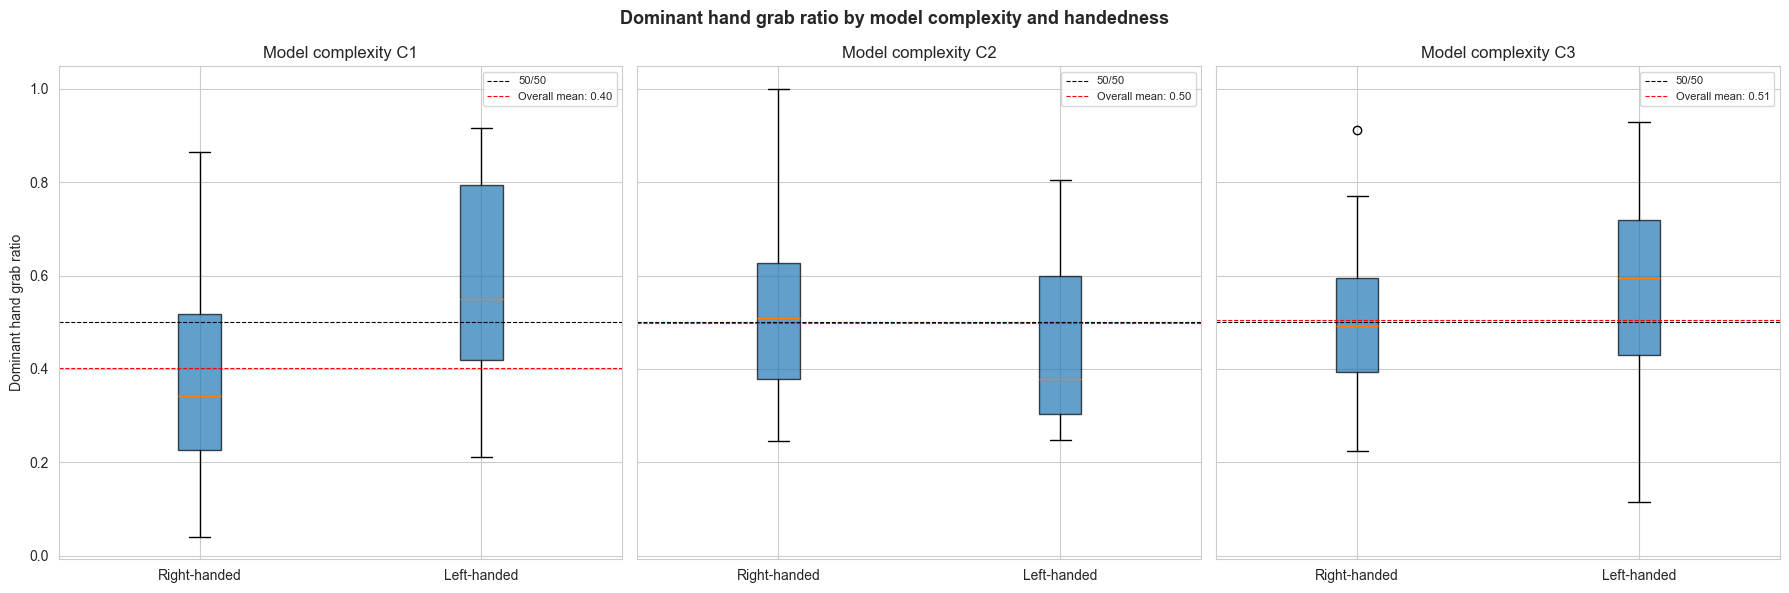

mean    std  median
model_complexity handedness                      
C1               left        0.579  0.274   0.550
                 right       0.377  0.190   0.341
C2               left        0.460  0.223   0.377
                 right       0.510  0.177   0.509
C3               left        0.561  0.286   0.595
                 right       0.503  0.152   0.491

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, complexity in enumerate(["C1", "C2", "C3"]):
    ax = axes[i]
    data = grab_counts_model[grab_counts_model["model_complexity"] == complexity]
    
    # split by handedness
    right_handed = data[data["handedness"] == "right"]["dominant_ratio"].dropna()
    left_handed = data[data["handedness"] == "left"]["dominant_ratio"].dropna()
    
    ax.boxplot(
        [right_handed, left_handed],
        tick_labels=["Right-handed", "Left-handed"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Overall mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(f"Model complexity {complexity}")
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)

plt.suptitle("Dominant hand grab ratio by model complexity and handedness", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# clean summary table
display(grab_counts_model.groupby(["model_complexity", "handedness"])["dominant_ratio"]
      .agg(["mean", "std", "median"])
      .round(3))

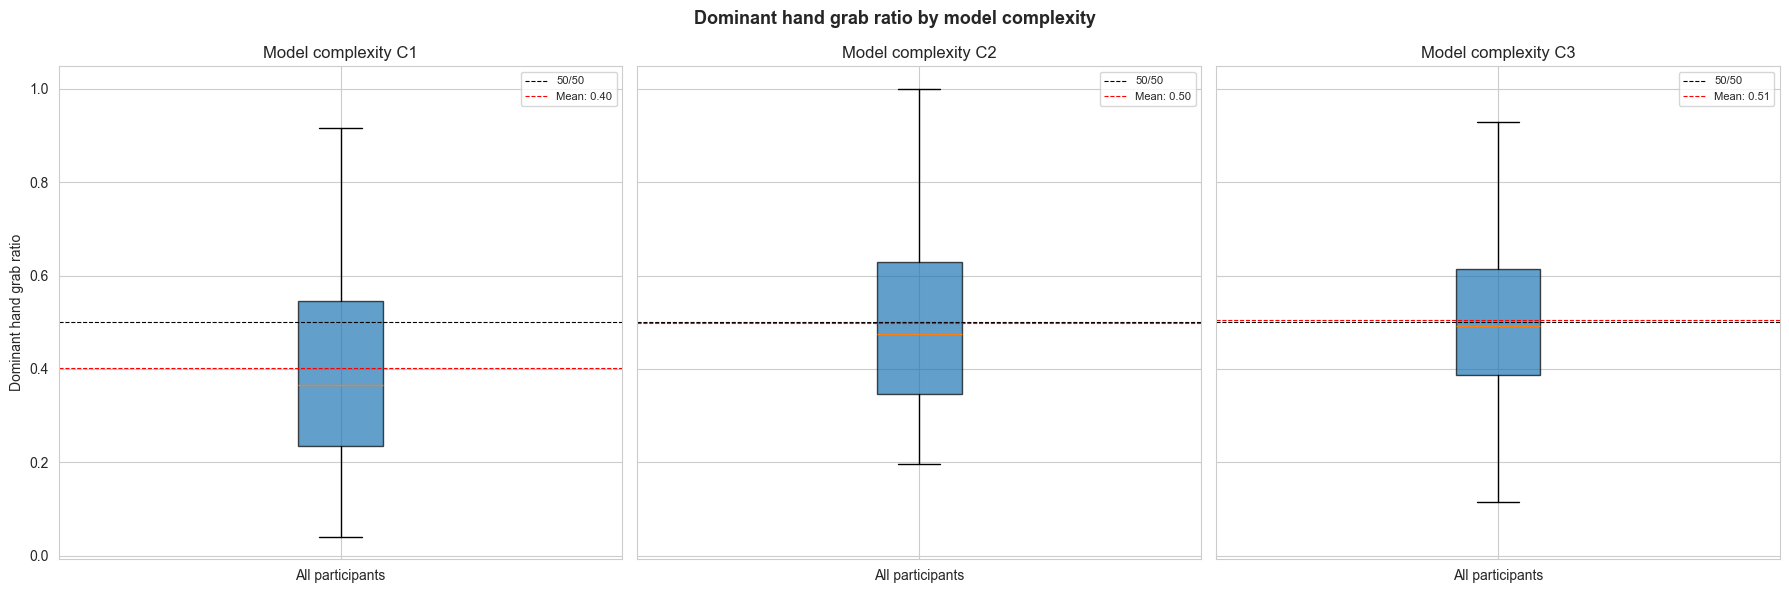

,mean,std,median
model_complexity,,,
C1,0.401,0.209,0.366
C2,0.497,0.185,0.474
C3,0.505,0.174,0.492


In [164]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, complexity in enumerate(["C1", "C2", "C3"]):
    ax = axes[i]
    data = grab_counts_model[grab_counts_model["model_complexity"] == complexity]
    
    ax.boxplot(
        [data["dominant_ratio"].dropna()],
        tick_labels=["All participants"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(f"Model complexity {complexity}")
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)

plt.suptitle("Dominant hand grab ratio by model complexity", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

display(grab_counts_model.groupby("model_complexity")["dominant_ratio"]
      .agg(["mean", "std", "median"])
      .round(3))

In [159]:
print(summary_all.groupby(["handedness", "hand", "model_complexity"]).size().unstack(fill_value=0))

# simpler — just handedness vs model complexity
print(summary_all.groupby(["handedness", "model_complexity"]).size().unstack(fill_value=0))

# or just hand vs model complexity
print(summary_all.groupby(["hand", "model_complexity"]).size().unstack(fill_value=0))


model_complexity   C1   C2   C3
handedness hand                
left       Left    57   98  133
           Right   36   83   97
right      Left   371  669  826
           Right  308  591  855
model_complexity   C1    C2    C3
handedness                       
left               93   181   230
right             679  1260  1681
model_complexity   C1   C2   C3
hand                           
Left              435  787  983
Right             355  688  977


In [120]:
#withou participant 004
print(summary_excl.groupby(["handedness", "hand", "model_complexity"]).size().unstack(fill_value=0))
print(summary_excl.groupby(["handedness", "model_complexity"]).size().unstack(fill_value=0))
print(summary_excl.groupby(["hand", "model_complexity"]).size().unstack(fill_value=0))

model_complexity   C1   C2   C3
handedness hand                
left       Left    57   98  133
           Right   36   83   97
right      Left   370  669  826
           Right  308  589  855
model_complexity   C1    C2    C3
handedness                       
left               93   181   230
right             678  1258  1681
model_complexity   C1   C2    C3
hand                            
Left              462  816  1022
Right             373  711  1017


In [121]:
print(EXCLUDE_PARTICIPANTS)

{'040', '036'}


In [153]:
events_all["participant_id"] = events_all["participant_id"].astype(str).str.zfill(3)
summary_all["participant_id"] = summary_all["participant_id"].astype(str).str.zfill(3)

events_all = events_all[~events_all["participant_id"].isin(EXCLUDE_PARTICIPANTS)]
summary_all = summary_all[~summary_all["participant_id"].isin(EXCLUDE_PARTICIPANTS)]

print("Remaining participants:", sorted(events_all["participant_id"].unique()))

Remaining participants: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '037', '038', '039', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


In [ ]:
#print(sorted(grab_counts["participant_id"].unique()))

['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


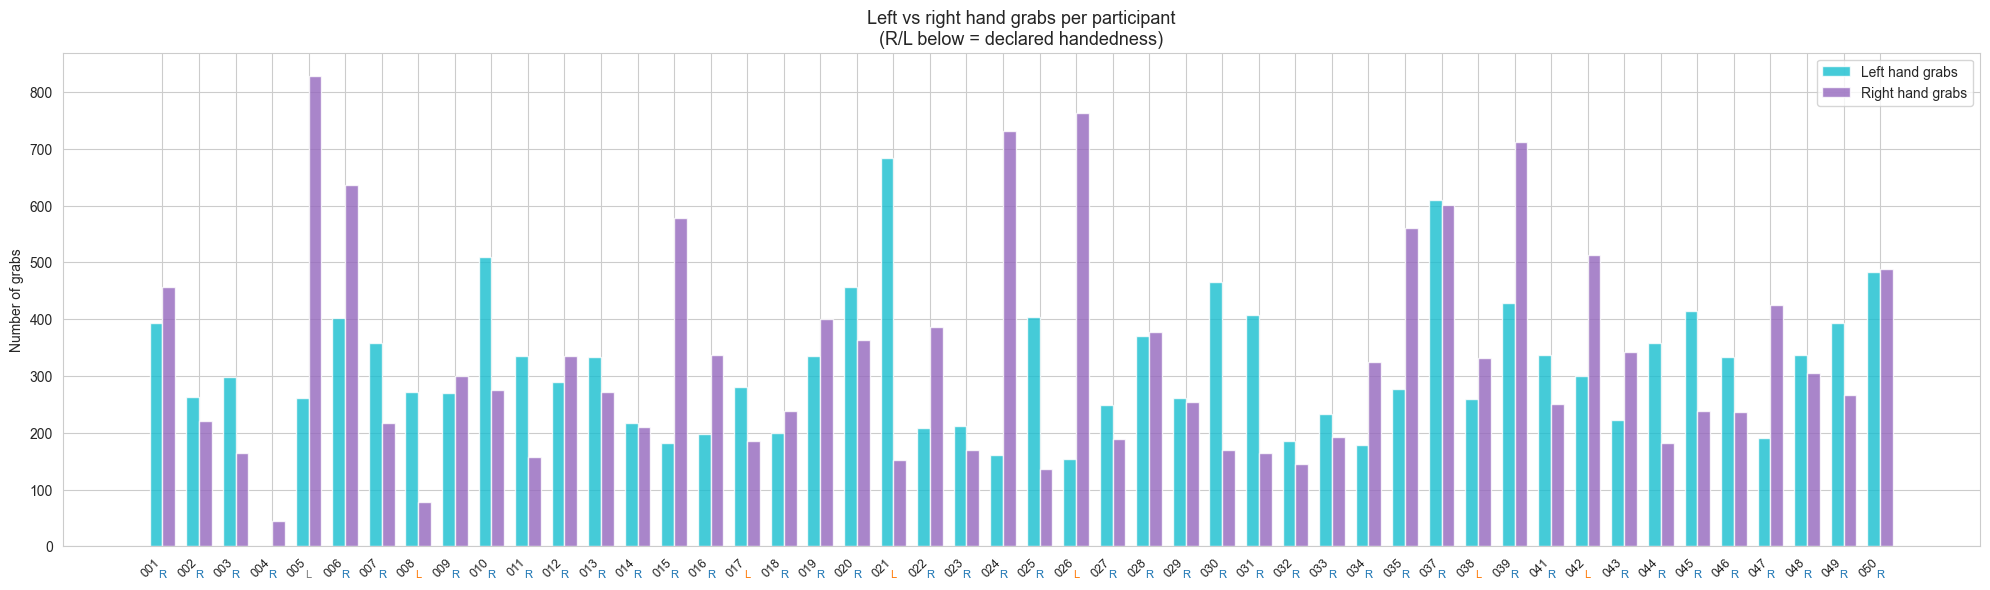

In [160]:
# --- Plot 1: Left vs right grabs per participant ---
fig, ax = plt.subplots(figsize=(20, 6))

x = range(len(grab_counts))
width = 0.35
colors = {"right": "tab:blue", "left": "tab:orange"}

ax.bar([i - width/2 for i in x], grab_counts["left_grabs"], width, label="Left hand grabs", color="tab:cyan", alpha=0.8)
ax.bar([i + width/2 for i in x], grab_counts["right_grabs"], width, label="Right hand grabs", color="tab:purple", alpha=0.8)

for i, (_, row) in enumerate(grab_counts.iterrows()):
    ax.text(i, -max(grab_counts["right_grabs"].max(), grab_counts["left_grabs"].max()) * 0.05,
            "R" if row["handedness"] == "right" else "L",
            ha="center", va="top", fontsize=8,
            color=colors.get(row["handedness"], "grey"))

ax.set_xticks(list(x))
ax.set_xticklabels(grab_counts["participant_id"], rotation=45, ha="right", fontsize=9)
ax.set_title("Left vs right hand grabs per participant\n(R/L below = declared handedness)", fontsize=13)
ax.set_ylabel("Number of grabs")
ax.legend()
plt.tight_layout()
plt.show()




/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_58415/3512527154.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_dc["participant_id"], rotation=45, ha="right", fontsize=9)


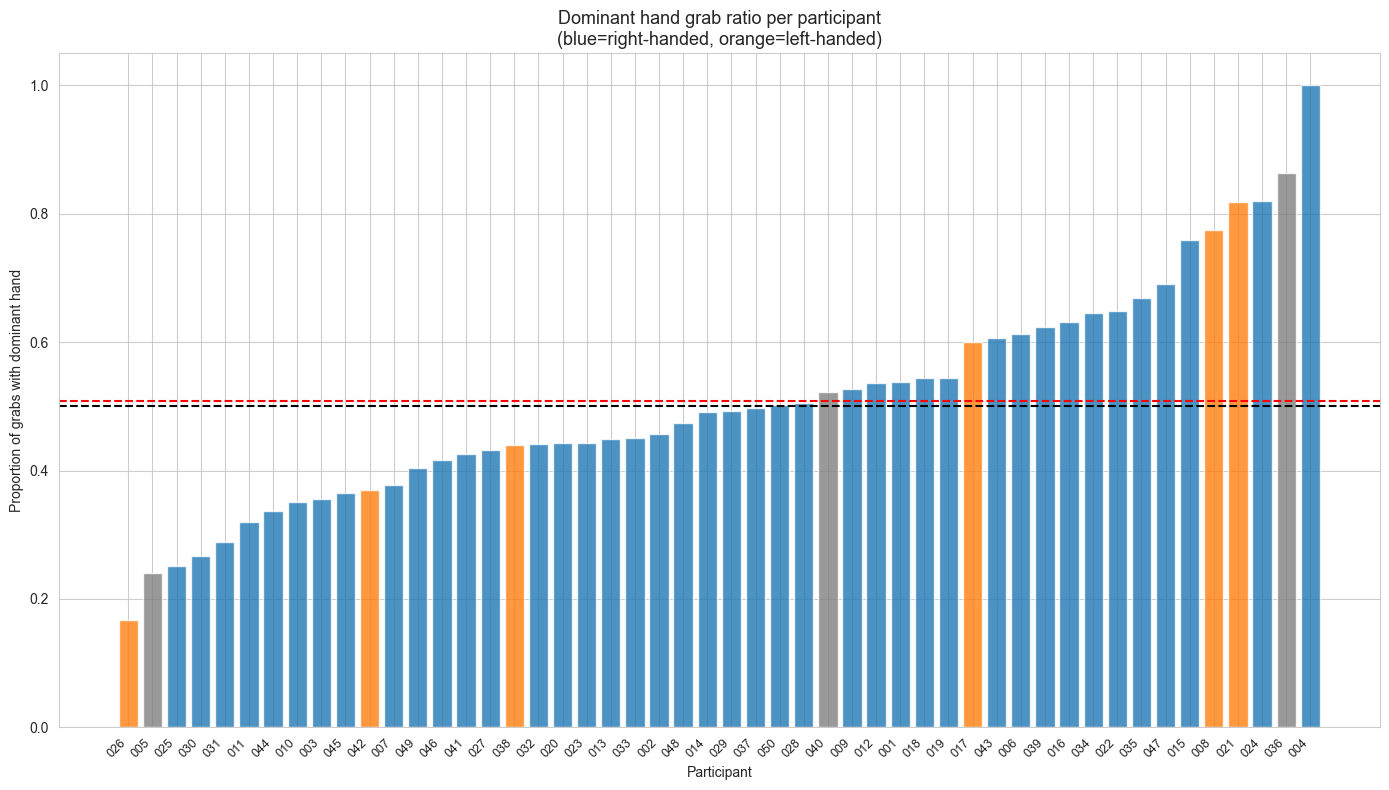

In [31]:
# --- Plot 2: Dominant hand ratio per participant ---
fig, ax = plt.subplots(figsize=(14, 8))

sorted_dc = grab_counts.sort_values("dominant_ratio")
bar_cols = [colors.get(h, "grey") for h in sorted_dc["handedness"]]
ax.bar(sorted_dc["participant_id"], sorted_dc["dominant_ratio"], color=bar_cols, alpha=0.8)
ax.axhline(0.5, color="black", linestyle="--", label="50/50")
ax.axhline(sorted_dc["dominant_ratio"].mean(), color="red", linestyle="--",
           label=f'Mean: {sorted_dc["dominant_ratio"].mean():.2f}')
ax.set_title("Dominant hand grab ratio per participant\n(blue=right-handed, orange=left-handed)", fontsize=13)
ax.set_ylabel("Proportion of grabs with dominant hand")
ax.set_xlabel("Participant")
ax.set_xticklabels(sorted_dc["participant_id"], rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

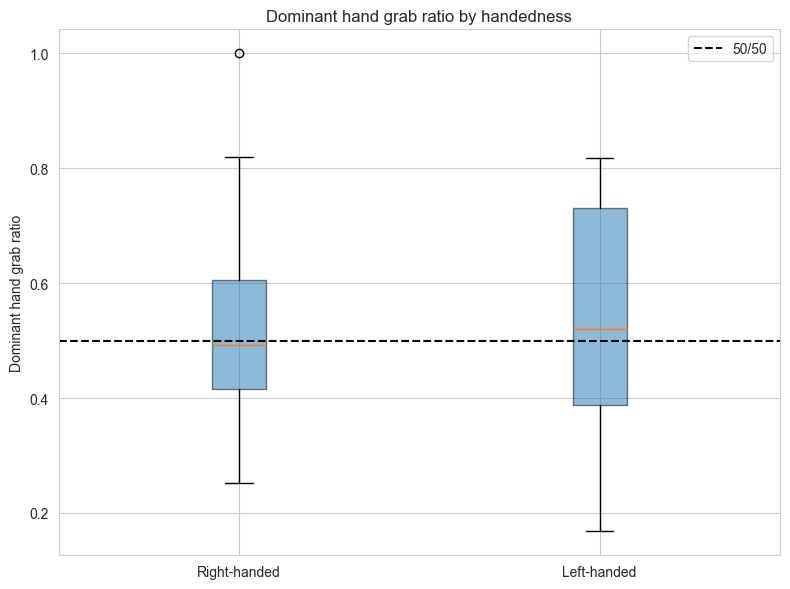

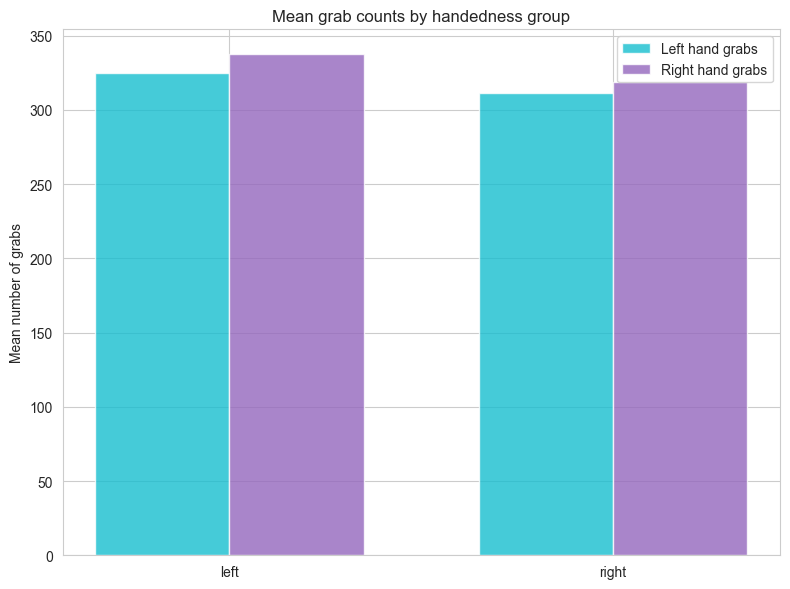


Summary by handedness group:


left_grabs          right_grabs          dominant_ratio       
                 mean      std        mean      std           mean    std
handedness                                                               
left          325.000  183.242     337.333  259.259          0.528  0.250
right         311.463  116.529     318.585  164.574          0.503  0.153

In [161]:
colors = {"right": "tab:blue", "left": "tab:orange"}
width = 0.35

# --- Plot 3: Boxplot — dominant ratio by handedness group ---
fig, ax = plt.subplots(figsize=(8, 6))

right_handed = grab_counts[grab_counts["handedness"] == "right"]["dominant_ratio"].dropna()
left_handed = grab_counts[grab_counts["handedness"] == "left"]["dominant_ratio"].dropna()

ax.boxplot([right_handed, left_handed], tick_labels=["Right-handed", "Left-handed"], patch_artist=True,
           boxprops=dict(facecolor="tab:blue", alpha=0.5))
ax.axhline(0.5, color="black", linestyle="--", label="50/50")
ax.set_title("Dominant hand grab ratio by handedness")
ax.set_ylabel("Dominant hand grab ratio")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 4: Overall mean grabs by handedness group ---
fig, ax = plt.subplots(figsize=(8, 6))

means = grab_counts.groupby("handedness")[["left_grabs", "right_grabs"]].mean()
x = range(len(means))
ax.bar([i - width/2 for i in x], means["left_grabs"], width, label="Left hand grabs", color="tab:cyan", alpha=0.8)
ax.bar([i + width/2 for i in x], means["right_grabs"], width, label="Right hand grabs", color="tab:purple", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(means.index, rotation=0)
ax.set_title("Mean grab counts by handedness group")
ax.set_ylabel("Mean number of grabs")
ax.legend()
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\nSummary by handedness group:")
display(grab_counts.groupby("handedness")[["left_grabs", "right_grabs", "dominant_ratio"]].agg(["mean", "std"]).round(3))

In [162]:
print(grab_counts.groupby("handedness")[["left_grabs", "right_grabs"]].sum())  # total grabs
print(grab_counts.groupby("handedness").size())  # group sizes

            left_grabs  right_grabs
handedness                         
left            1950.0       2024.0
right          12770.0      13062.0
handedness
left      6
right    41
dtype: int64


In [77]:
# find the participant with 100% dominant ratio
outlier = grab_counts[grab_counts["dominant_ratio"] == 1]
print(outlier[["participant_id", "handedness", "left_grabs", "right_grabs", "dominant_ratio"]])

  participant_id handedness  left_grabs  right_grabs  dominant_ratio
3            004      right           0           45             1.0


In [78]:
# grab counts per participant, hand AND condition
grab_counts_cond = (
    events_all.groupby(["participant_id", "condition_number", "hand"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"Left": "left_grabs", "Right": "right_grabs"})
    .reset_index()
)

# merge handedness
grab_counts_cond = grab_counts_cond.merge(handedness_df, on="participant_id", how="left")

# dominant/nondominant ratio per condition
grab_counts_cond["dominant_grabs"] = grab_counts_cond.apply(
    lambda r: r["right_grabs"] if r["handedness"] == "right" else r["left_grabs"], axis=1
)
grab_counts_cond["nondominant_grabs"] = grab_counts_cond.apply(
    lambda r: r["left_grabs"] if r["handedness"] == "right" else r["right_grabs"], axis=1
)
grab_counts_cond["dominant_ratio"] = grab_counts_cond["dominant_grabs"] / (
    grab_counts_cond["dominant_grabs"] + grab_counts_cond["nondominant_grabs"]
)

print(grab_counts_cond.head(15))

   participant_id  condition_number  left_grabs  right_grabs handedness  \
0             001                 1          69          215      right   
1             001                 2         136          129      right   
2             001                 3         188          113      right   
3             002                 1          50           82      right   
4             002                 2          98           85      right   
5             002                 3         115           54      right   
6             003                 1          89           52      right   
7             003                 2         114           35      right   
8             003                 3          95           78      right   
9             004                 1           0           45      right   
10            005                 1          84          202        NaN   
11            005                 2          48          356        NaN   
12            005        

In [79]:
'''events_all = events_all[events_all["participant_id"] != "004"]
summary_all = summary_all[summary_all["participant_id"] != "004"]
grab_counts_cond = grab_counts_cond[grab_counts_cond["participant_id"] != "004"]
grab_counts = grab_counts[grab_counts["participant_id"] != "004"]
handedness_df = handedness_df[handedness_df["participant_id"] != "004"]
'''

'events_all = events_all[events_all["participant_id"] != "004"]\nsummary_all = summary_all[summary_all["participant_id"] != "004"]\ngrab_counts_cond = grab_counts_cond[grab_counts_cond["participant_id"] != "004"]\ngrab_counts = grab_counts[grab_counts["participant_id"] != "004"]\nhandedness_df = handedness_df[handedness_df["participant_id"] != "004"]\n'

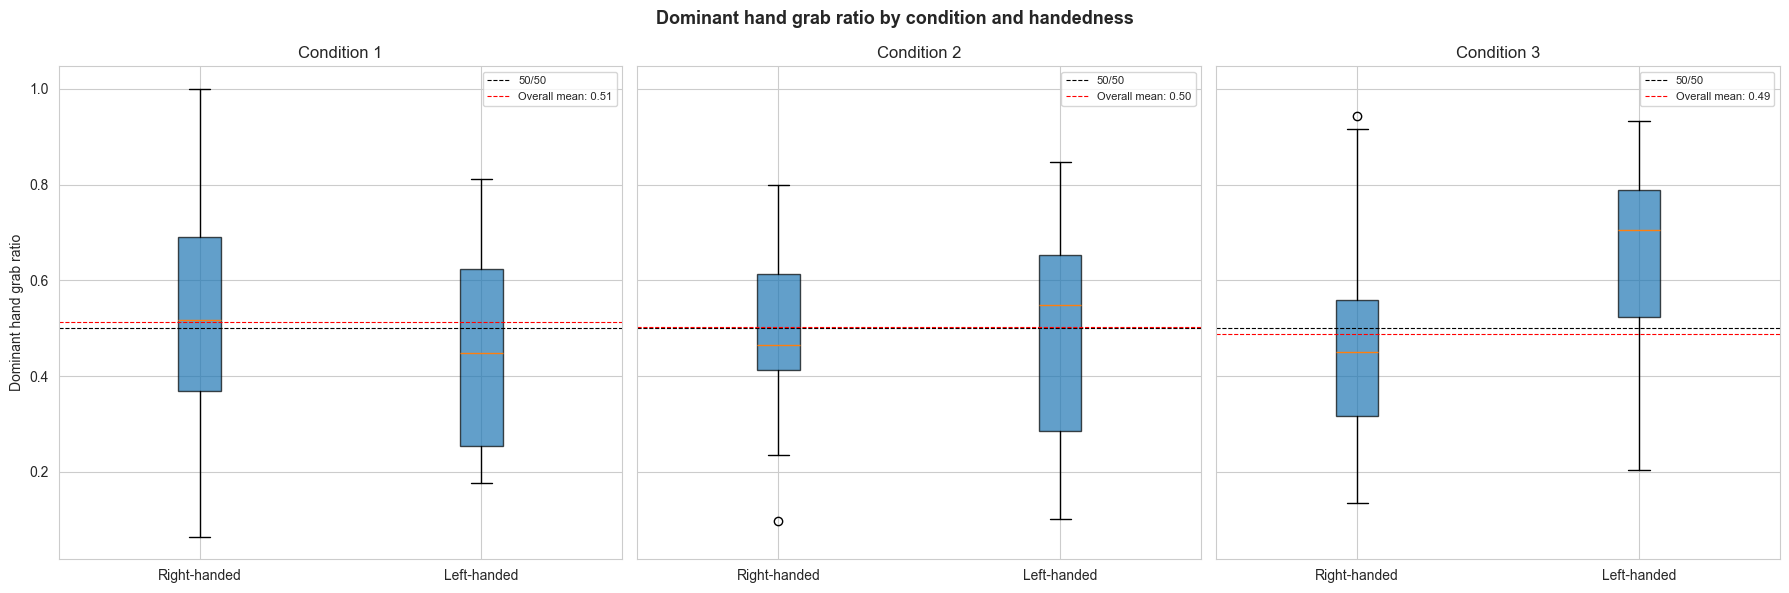

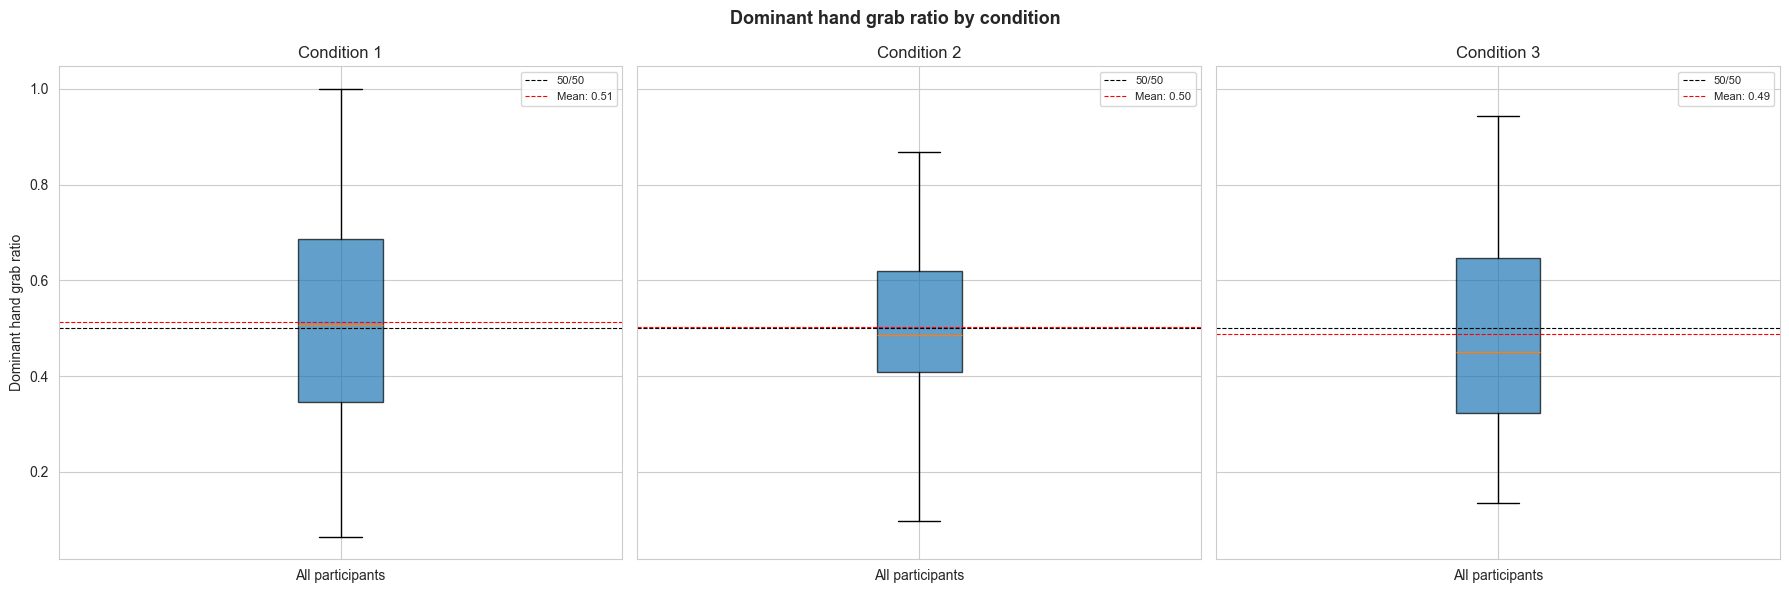


Mean dominant ratio by condition and handedness:


mean    std  median
condition_number handedness                      
1                left        0.459  0.251   0.448
                 right       0.520  0.213   0.518
2                left        0.489  0.284   0.548
                 right       0.501  0.156   0.466
3                left        0.638  0.263   0.706
                 right       0.460  0.201   0.450


Mean dominant ratio by condition:


,mean,std,median
condition_number,,,
1,0.513,0.216,0.507
2,0.502,0.185,0.487
3,0.487,0.219,0.451


In [92]:
# --- By condition, split by handedness ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
condition_labels = {1: "Condition 1", 2: "Condition 2", 3: "Condition 3"}

for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    data = grab_counts_cond[grab_counts_cond["condition_number"] == cond]
    right_handed = data[data["handedness"] == "right"]["dominant_ratio"].dropna()
    left_handed = data[data["handedness"] == "left"]["dominant_ratio"].dropna()
    
    ax.boxplot(
        [right_handed, left_handed],
        tick_labels=["Right-handed", "Left-handed"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Overall mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)

plt.suptitle("Dominant hand grab ratio by condition and handedness",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- By condition, all participants ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    data = grab_counts_cond[grab_counts_cond["condition_number"] == cond]
    
    ax.boxplot(
        [data["dominant_ratio"].dropna()],
        tick_labels=["All participants"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)

plt.suptitle("Dominant hand grab ratio by condition",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Summary tables ---
print("\nMean dominant ratio by condition and handedness:")
display(grab_counts_cond.groupby(["condition_number", "handedness"])["dominant_ratio"]
      .agg(["mean", "std", "median"])
      .round(3))

print("\nMean dominant ratio by condition:")
display(grab_counts_cond.groupby("condition_number")["dominant_ratio"]
      .agg(["mean", "std", "median"])
      .round(3))

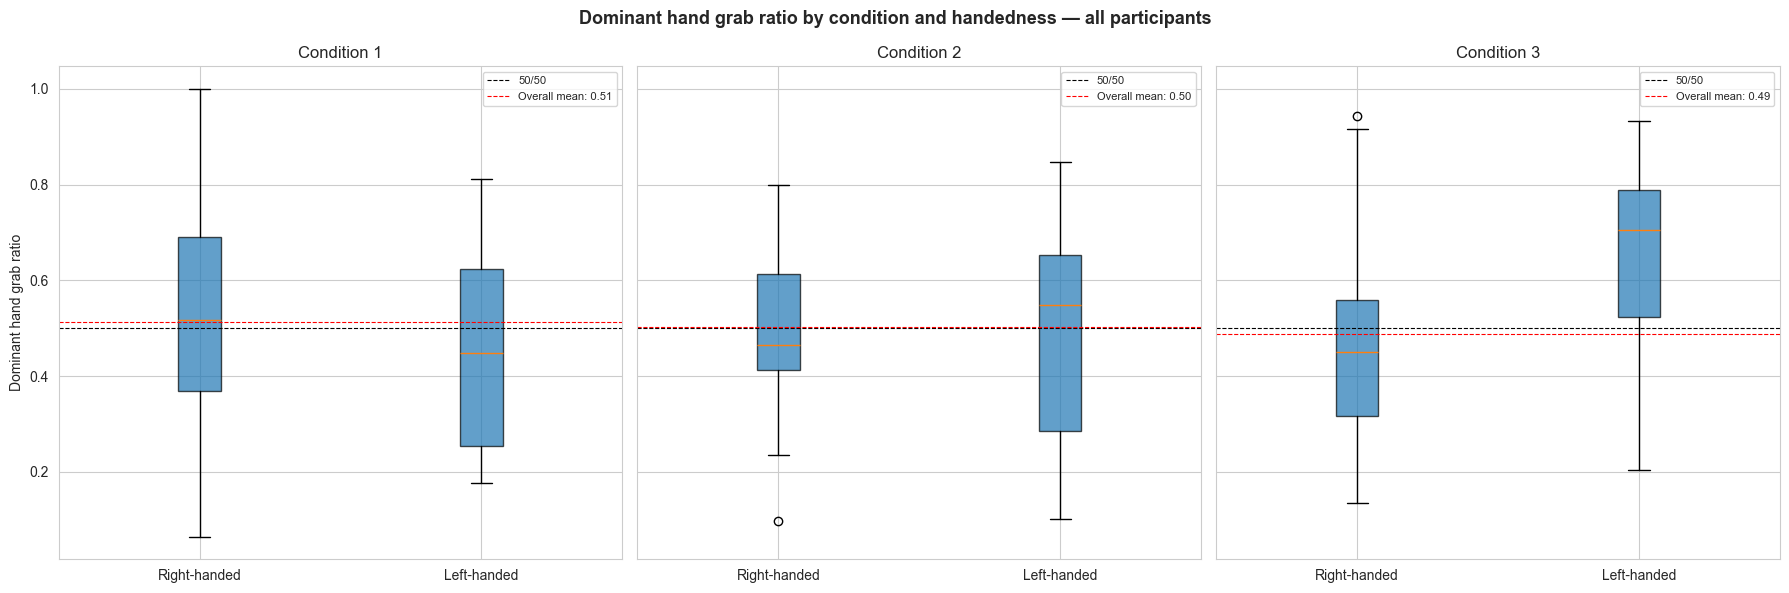

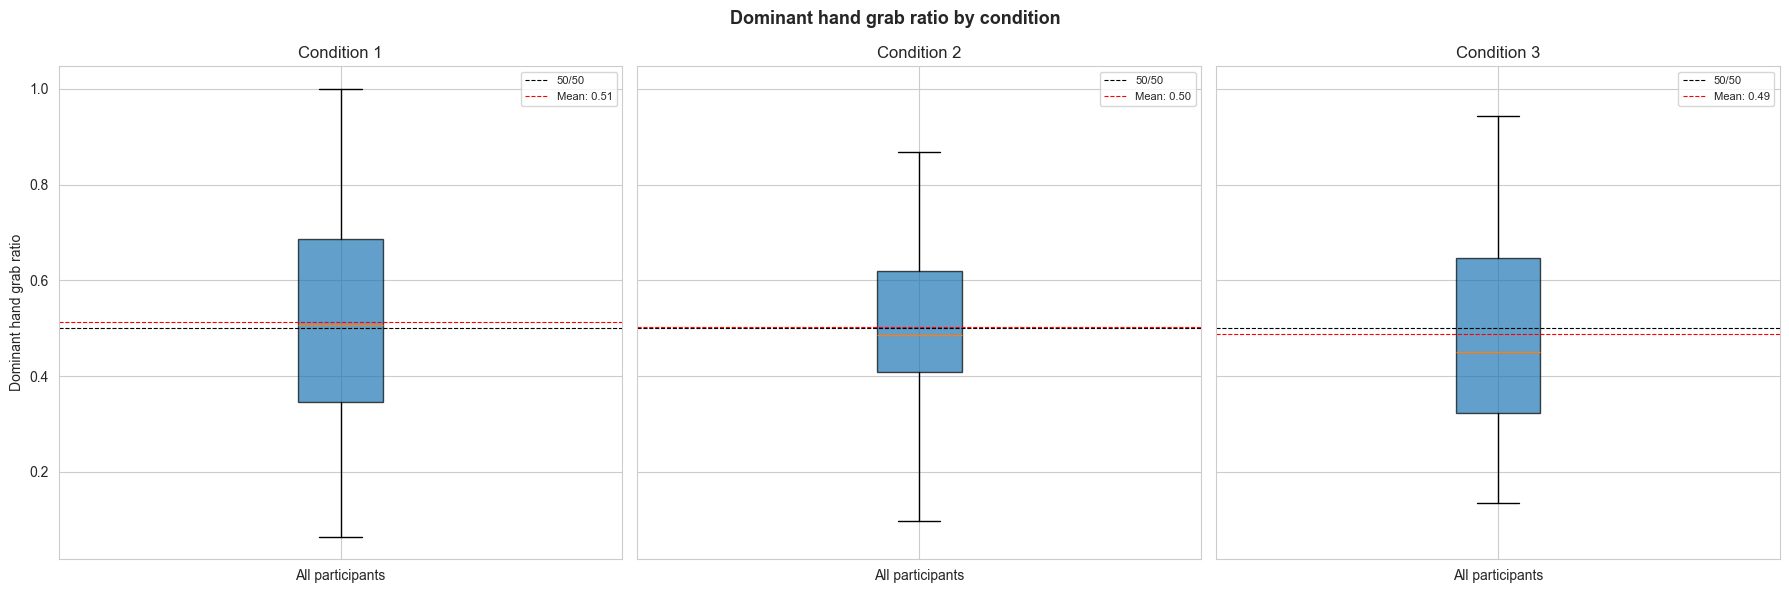


Mean dominant ratio by condition and handedness:
                              mean    std  median
condition_number handedness                      
1                left        0.459  0.251   0.448
                 right       0.520  0.213   0.518
2                left        0.489  0.284   0.548
                 right       0.501  0.156   0.466
3                left        0.638  0.263   0.706
                 right       0.460  0.201   0.450

Mean dominant ratio by condition:
                   mean    std  median
condition_number                      
1                 0.513  0.216   0.507
2                 0.502  0.185   0.487
3                 0.487  0.219   0.451


In [93]:
condition_labels = {1: "Condition 1", 2: "Condition 2", 3: "Condition 3"}

# ================================================================
# BY CONDITION — ALL PARTICIPANTS
# ================================================================

# --- Split by handedness ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    data = grab_counts_cond[grab_counts_cond["condition_number"] == cond]
    right_handed = data[data["handedness"] == "right"]["dominant_ratio"].dropna()
    left_handed = data[data["handedness"] == "left"]["dominant_ratio"].dropna()
    ax.boxplot(
        [right_handed, left_handed],
        tick_labels=["Right-handed", "Left-handed"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Overall mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)
plt.suptitle("Dominant hand grab ratio by condition and handedness — all participants",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- All participants combined ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    data = grab_counts_cond[grab_counts_cond["condition_number"] == cond]
    ax.boxplot(
        [data["dominant_ratio"].dropna()],
        tick_labels=["All participants"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)
plt.suptitle("Dominant hand grab ratio by condition",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMean dominant ratio by condition and handedness:")
print(grab_counts_cond.groupby(["condition_number", "handedness"])["dominant_ratio"]
      .agg(["mean", "std", "median"]).round(3))
print("\nMean dominant ratio by condition:")
print(grab_counts_cond.groupby("condition_number")["dominant_ratio"]
      .agg(["mean", "std", "median"]).round(3))

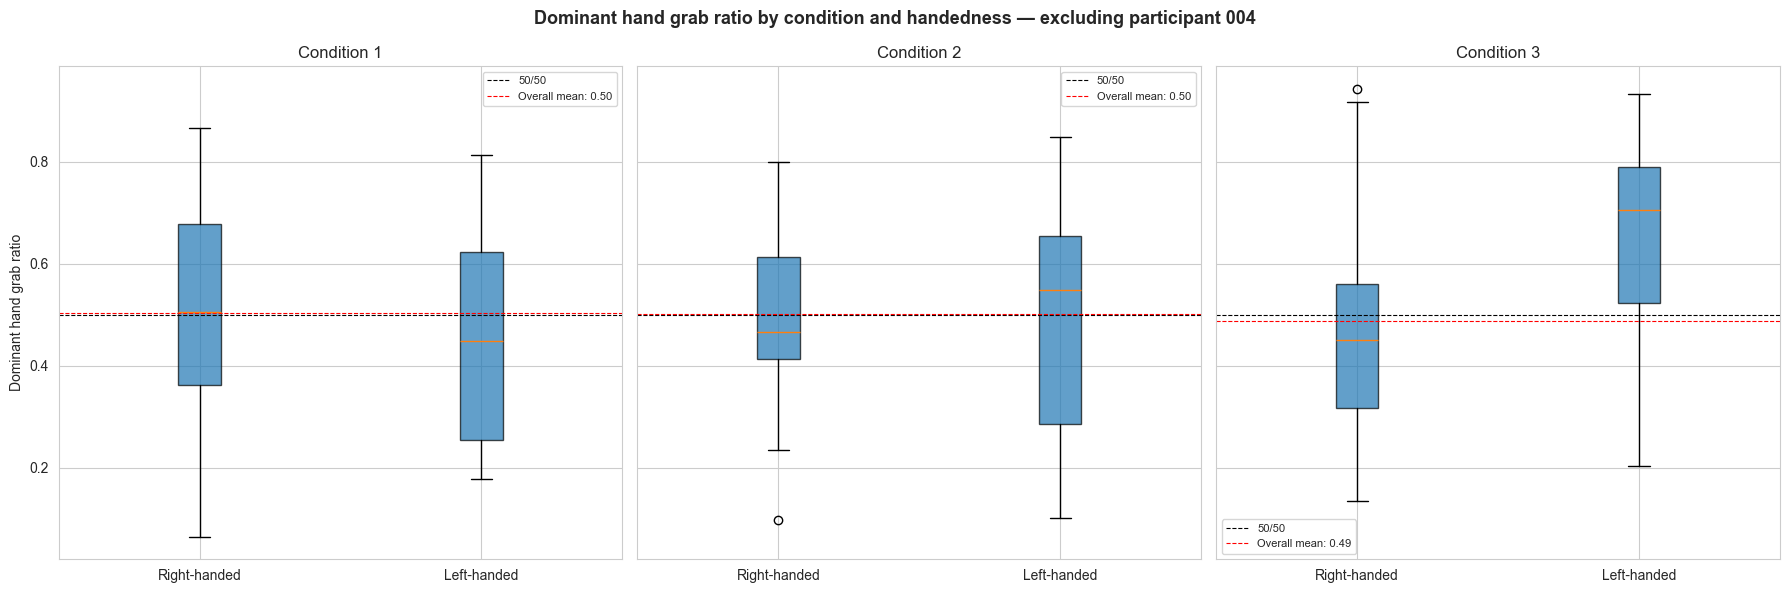

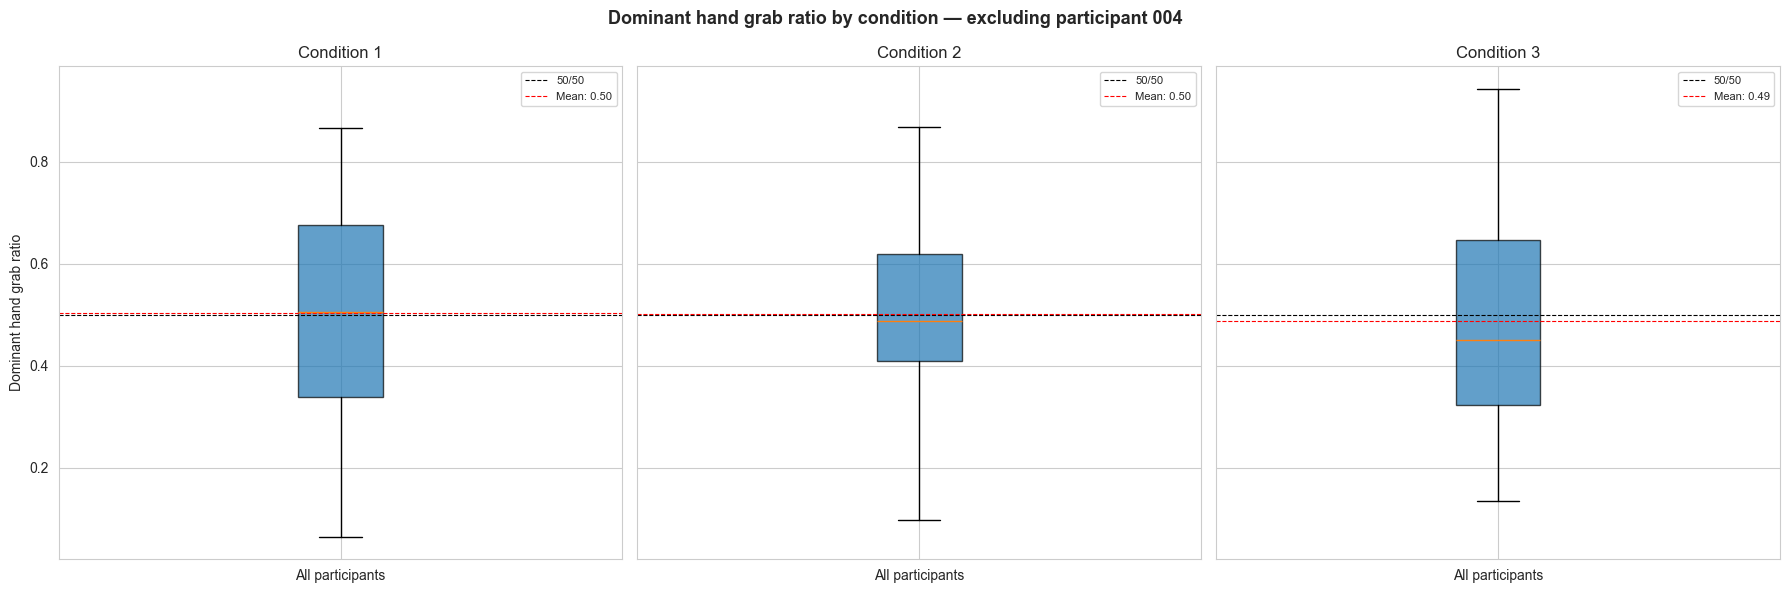


Mean dominant ratio by condition and handedness — excluding participant 004:
                              mean    std  median
condition_number handedness                      
1                left        0.459  0.251   0.448
                 right       0.508  0.201   0.505
2                left        0.489  0.284   0.548
                 right       0.501  0.156   0.466
3                left        0.638  0.263   0.706
                 right       0.460  0.201   0.450

Mean dominant ratio by condition — excluding participant 004:
                   mean    std  median
condition_number                      
1                 0.504  0.206   0.504
2                 0.502  0.185   0.487
3                 0.487  0.219   0.451


In [82]:
# ================================================================
# BY CONDITION — EXCLUDING PARTICIPANT 004
# ================================================================

# recreate grab_counts_cond without 004
grab_counts_cond_excl = (
    events_excl.groupby(["participant_id", "condition_number", "hand"])
    .size()
    .reset_index(name="grab_count")
    .pivot_table(
        index=["participant_id", "condition_number"],
        columns="hand",
        values="grab_count",
        fill_value=0
    )
    .rename(columns={"Left": "left_grabs", "Right": "right_grabs"})
    .reset_index()
)
grab_counts_cond_excl = grab_counts_cond_excl.merge(handedness_excl, on="participant_id", how="left")
grab_counts_cond_excl["dominant_grabs"] = grab_counts_cond_excl.apply(
    lambda r: r["right_grabs"] if r["handedness"] == "right" else r["left_grabs"], axis=1
)
grab_counts_cond_excl["nondominant_grabs"] = grab_counts_cond_excl.apply(
    lambda r: r["left_grabs"] if r["handedness"] == "right" else r["right_grabs"], axis=1
)
grab_counts_cond_excl["dominant_ratio"] = grab_counts_cond_excl["dominant_grabs"] / (
    grab_counts_cond_excl["dominant_grabs"] + grab_counts_cond_excl["nondominant_grabs"]
)

# --- Split by handedness ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    data = grab_counts_cond_excl[grab_counts_cond_excl["condition_number"] == cond]
    right_handed = data[data["handedness"] == "right"]["dominant_ratio"].dropna()
    left_handed = data[data["handedness"] == "left"]["dominant_ratio"].dropna()
    ax.boxplot(
        [right_handed, left_handed],
        tick_labels=["Right-handed", "Left-handed"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Overall mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)
plt.suptitle("Dominant hand grab ratio by condition and handedness — excluding participant 004",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- All participants combined ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    data = grab_counts_cond_excl[grab_counts_cond_excl["condition_number"] == cond]
    ax.boxplot(
        [data["dominant_ratio"].dropna()],
        tick_labels=["All participants"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
    )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(data["dominant_ratio"].mean(), color="red", linestyle="--",
               linewidth=0.8, label=f'Mean: {data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_ylabel("Dominant hand grab ratio" if i == 0 else "")
    ax.legend(fontsize=8)
plt.suptitle("Dominant hand grab ratio by condition — excluding participant 004",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMean dominant ratio by condition and handedness — excluding participant 004:")
print(grab_counts_cond_excl.groupby(["condition_number", "handedness"])["dominant_ratio"]
      .agg(["mean", "std", "median"]).round(3))
print("\nMean dominant ratio by condition — excluding participant 004:")
print(grab_counts_cond_excl.groupby("condition_number")["dominant_ratio"]
      .agg(["mean", "std", "median"]).round(3))

In [165]:
# --- per participant summary from events_all ---
participant_summary = (
    events_all.groupby("participant_id")
    .agg(
        n_conditions=("condition_number", "nunique"),
        n_trials=("trial_number", "nunique"),
        n_complexities=("model_complexity", "nunique"),
        complexities=("model_complexity", lambda x: ", ".join(sorted(x.dropna().unique()))),
        total_grabs=("grab_idx_in_trial", "count"),
    )
    .reset_index()
)

# --- merge with grab_counts ---
participant_summary = participant_summary.merge(
    grab_counts[["participant_id", "handedness", "left_grabs", "right_grabs", "dominant_grabs", "nondominant_grabs", "dominant_ratio"]],
    on="participant_id", how="left"
)

# --- add qc summary per participant ---
qc_summary = qc_all.groupby("pid").agg(
    total_fixation_runs=("n_fixation_runs", "sum"),
    total_grab_episodes=("n_grab_episodes_all", "sum"),
    total_resource_grabs=("n_grab_episodes_resource_start", "sum"),
    total_grabs_with_fixations=("n_grabs_with_fixations", "sum"),
    total_grabs_without_fixations=("n_grabs_without_fixations", "sum"),
).reset_index().rename(columns={"pid": "participant_id"})

participant_summary = participant_summary.merge(qc_summary, on="participant_id", how="left")

# --- display ---
participant_summary["participant_id"] = participant_summary["participant_id"].astype(str).str.zfill(3)
participant_summary = participant_summary.sort_values("participant_id").reset_index(drop=True)

print(f"Total participants: {len(participant_summary)}")
display(participant_summary)

# --- save ---
participant_summary.to_csv(OUTPUT_DIR / "participant_summary.csv", index=False)
participant_summary.to_excel(OUTPUT_DIR / "participant_summary.xlsx", index=False)
print("Saved!")

Total participants: 48


,participant_id,n_conditions,n_trials,n_complexities,complexities,total_grabs,handedness,left_grabs,right_grabs,dominant_grabs,nondominant_grabs,dominant_ratio,total_fixation_runs,total_grab_episodes,total_resource_grabs,total_grabs_with_fixations,total_grabs_without_fixations
0,001,3,6,3,"C1, C2, C3",850,right,393.0,457.0,457.0,393.0,0.537647,NaN,NaN,NaN,NaN,NaN
1,002,3,6,3,"C1, C2, C3",484,right,263.0,221.0,221.0,263.0,0.456612,NaN,NaN,NaN,NaN,NaN
2,003,3,6,3,"C1, C2, C3",463,right,298.0,165.0,165.0,298.0,0.356371,NaN,NaN,NaN,NaN,NaN
3,004,1,1,1,C2,45,right,0.0,45.0,45.0,0.0,1.000000,NaN,NaN,NaN,NaN,NaN
4,005,3,6,3,"C1, C2, C3",1089,NaN,261.0,828.0,261.0,828.0,0.239669,NaN,NaN,NaN,NaN,NaN
5,006,3,6,3,"C1, C2, C3",1040,right,403.0,637.0,637.0,403.0,0.612500,NaN,NaN,NaN,NaN,NaN
6,007,3,6,3,"C1, C2, C3",575,right,358.0,217.0,217.0,358.0,0.377391,NaN,NaN,NaN,NaN,NaN
7,008,3,6,3,"C1, C2, C3",351,left,272.0,79.0,272.0,79.0,0.774929,NaN,NaN,NaN,NaN,NaN
8,009,3,6,3,"C1, C2, C3",570,right,270.0,300.0,300.0,270.0,0.526316,NaN,NaN,NaN,NaN,NaN
9,010,3,6,3,"C1, C2, C3",784,right,509.0,275.0,275.0,509.0,0.350765,NaN,NaN,NaN,NaN,NaN


Saved!


In [169]:
EXCLUDE_SUMMARY = {"004", "036", "040"}

participant_summary_excl = participant_summary[
    ~participant_summary["participant_id"].isin(EXCLUDE_SUMMARY)
]

# --- Overall counts ---
overall_counts_excl = pd.DataFrame({
    "metric": ["Total grabs", "Total left grabs", "Total right grabs",
                "Total dominant grabs", "Total nondominant grabs"],
    "total": [
        participant_summary_excl["total_grabs"].sum(),
        participant_summary_excl["total_left_grabs"].sum(),
        participant_summary_excl["total_right_grabs"].sum(),
        participant_summary_excl["total_dominant_grabs"].sum(),
        participant_summary_excl["total_nondominant_grabs"].sum(),
    ]
})

# --- Per participant stats ---
per_participant_stats_excl = (
    participant_summary_excl[["total_grabs", "total_left_grabs", "total_right_grabs",
                               "total_dominant_grabs", "total_nondominant_grabs",
                               "mean_dominant_ratio"]]
    .agg(["mean", "std", "min", "max"])
    .round(3)
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

print(f"Overall grab counts (excluding {EXCLUDE_SUMMARY}):")
display(overall_counts_excl)

print(f"\nPer participant descriptive stats (excluding {EXCLUDE_SUMMARY}):")
display(per_participant_stats_excl)

Overall grab counts (excluding {'040', '036', '004'}):


,metric,total
0,Total grabs,30850.0
1,Total left grabs,14981.0
2,Total right grabs,15869.0
3,Total dominant grabs,15228.0
4,Total nondominant grabs,15622.0



Per participant descriptive stats (excluding {'040', '036', '004'}):


,metric,mean,std,min,max
0,total_grabs,656.383,210.677,331.000,1212.00
1,total_left_grabs,318.745,115.645,154.000,684.00
2,total_right_grabs,337.638,185.869,79.000,828.00
3,total_dominant_grabs,324.000,160.069,136.000,731.00
4,total_nondominant_grabs,332.383,149.817,79.000,828.00
5,mean_dominant_ratio,0.490,0.152,0.168,0.82


In [83]:
# ================================================================
# GRAB COUNTS BY MODEL COMPLEXITY
# ================================================================

# --- With all participants ---
print("=== MODEL COMPLEXITY — ALL PARTICIPANTS ===\n")
print("Handedness + Hand + Complexity:")
print(summary_all.groupby(["handedness", "hand", "model_complexity"]).size().unstack(fill_value=0))
print("\nHandedness + Complexity:")
print(summary_all.groupby(["handedness", "model_complexity"]).size().unstack(fill_value=0))
print("\nHand + Complexity:")
print(summary_all.groupby(["hand", "model_complexity"]).size().unstack(fill_value=0))

# --- Without participant 004 ---
print("\n=== MODEL COMPLEXITY — EXCLUDING PARTICIPANT 004 ===\n")
print("Handedness + Hand + Complexity:")
print(summary_excl.groupby(["handedness", "hand", "model_complexity"]).size().unstack(fill_value=0))
print("\nHandedness + Complexity:")
print(summary_excl.groupby(["handedness", "model_complexity"]).size().unstack(fill_value=0))
print("\nHand + Complexity:")
print(summary_excl.groupby(["hand", "model_complexity"]).size().unstack(fill_value=0))


# ================================================================
# GRAB COUNTS BY CONDITION
# ================================================================

# --- With all participants ---
print("=== CONDITION — ALL PARTICIPANTS ===\n")
print("Handedness + Hand + Condition:")
print(summary_all.groupby(["handedness", "hand", "condition_number"]).size().unstack(fill_value=0))
print("\nHandedness + Condition:")
print(summary_all.groupby(["handedness", "condition_number"]).size().unstack(fill_value=0))
print("\nHand + Condition:")
print(summary_all.groupby(["hand", "condition_number"]).size().unstack(fill_value=0))

# --- Without participant 004 ---
print("\n=== CONDITION — EXCLUDING PARTICIPANT 004 ===\n")
print("Handedness + Hand + Condition:")
print(summary_excl.groupby(["handedness", "hand", "condition_number"]).size().unstack(fill_value=0))
print("\nHandedness + Condition:")
print(summary_excl.groupby(["handedness", "condition_number"]).size().unstack(fill_value=0))
print("\nHand + Condition:")
print(summary_excl.groupby(["hand", "condition_number"]).size().unstack(fill_value=0))

=== MODEL COMPLEXITY — ALL PARTICIPANTS ===

Handedness + Hand + Complexity:
model_complexity   C1   C2   C3
handedness hand                
left       Left    57   98  133
           Right   36   83   97
right      Left   371  669  826
           Right  308  591  855

Handedness + Complexity:
model_complexity   C1    C2    C3
handedness                       
left               93   181   230
right             679  1260  1681

Hand + Complexity:
model_complexity   C1   C2    C3
hand                            
Left              463  816  1022
Right             373  713  1017

=== MODEL COMPLEXITY — EXCLUDING PARTICIPANT 004 ===

Handedness + Hand + Complexity:
model_complexity   C1   C2   C3
handedness hand                
left       Left    57   98  133
           Right   36   83   97
right      Left   370  669  826
           Right  308  589  855

Handedness + Complexity:
model_complexity   C1    C2    C3
handedness                       
left               93   181   230
right     

In [84]:
print(f"Total grabs with 004: {len(summary_all)}")
print(f"Total grabs without 004: {len(summary_excl)}")
print(f"Difference: {len(summary_all) - len(summary_excl)} grabs from participant 004")

Total grabs with 004: 4404
Total grabs without 004: 4401
Difference: 3 grabs from participant 004


In [85]:
# find participant 004's file
p004_file = [f for f in csv_files if "004" in f.stem][0]
df_004 = pd.read_csv(p004_file, low_memory=False)

print(f"Total rows: {len(df_004)}")
print(f"Grabbed name values: {df_004['LeftHand_grabbed_name'].notna().sum()} left, {df_004['RightHand_grabbed_name'].notna().sum()} right")
print(f"LeftFootArea values: {df_004['LeftFootArea'].value_counts(dropna=False)}")
print(f"RightFootArea values: {df_004['RightFootArea'].value_counts(dropna=False)}")

Total rows: 180076
Grabbed name values: 39521 left, 74107 right
LeftFootArea values: LeftFootArea
Work        148248
Resource     23845
Model         7983
Name: count, dtype: int64
RightFootArea values: RightFootArea
Work        143974
Resource     28771
Model         7246
Middle          85
Name: count, dtype: int64


In [86]:
out_004 = build_grab_fixation_outputs(df_004)

print(f"All grab episodes: {len(out_004['all_grab_episodes'])}")
print(f"Resource grabs: {len(out_004['grab_events'])}")
print(f"grab_start_area values: {out_004['all_grab_episodes']['grab_start_area'].value_counts()}")
print(f"\nInferred bounds:")
from pprint import pprint
pprint(_infer_resource_bounds(df_004))

All grab episodes: 22
Resource grabs: 3
grab_start_area values: grab_start_area
NonResource    19
Resource        3
Name: count, dtype: int64

Inferred bounds:
{'x_max': np.float64(0.2526220263636363),
 'x_min': np.float64(-0.28707458499999994),
 'y_max': np.float64(1.222334),
 'y_min': np.float64(-0.05),
 'z_max': np.float64(0.05),
 'z_min': np.float64(-1.5713540000000001)}


In [87]:
print(f"Total rows: {len(df_004)}")
print(f"Trials: {df_004['trial_number'].unique()}")
print(f"Conditions: {df_004['condition_number'].unique()}")
print(f"LeftHand_grabbed_name non-null: {df_004['LeftHand_grabbed_name'].notna().sum()}")
print(f"RightHand_grabbed_name non-null: {df_004['RightHand_grabbed_name'].notna().sum()}")
print(f"Brick grabs left: {df_004['LeftHand_grabbed_name'].apply(is_brick_name).sum()}")
print(f"Brick grabs right: {df_004['RightHand_grabbed_name'].apply(is_brick_name).sum()}")

Total rows: 180076
Trials: [0 1 2 3]
Conditions: [0 1]
LeftHand_grabbed_name non-null: 39521
RightHand_grabbed_name non-null: 74107
Brick grabs left: 7985
Brick grabs right: 10030


In [88]:
print(df_004["LeftFootArea"].value_counts(dropna=False))
print(df_004["RightFootArea"].value_counts(dropna=False))

# check what grab start areas are being detected
print(out_004["all_grab_episodes"]["grab_start_area"].value_counts())

# check bounds
from pprint import pprint
pprint(_infer_resource_bounds(df_004))

LeftFootArea
Work        148248
Resource     23845
Model         7983
Name: count, dtype: int64
RightFootArea
Work        143974
Resource     28771
Model         7246
Middle          85
Name: count, dtype: int64
grab_start_area
NonResource    19
Resource        3
Name: count, dtype: int64
{'x_max': np.float64(0.2526220263636363),
 'x_min': np.float64(-0.28707458499999994),
 'y_max': np.float64(1.222334),
 'y_min': np.float64(-0.05),
 'z_max': np.float64(0.05),
 'z_min': np.float64(-1.5713540000000001)}


In [89]:
print(df_004.groupby(["condition_number", "trial_number"]).size())

condition_number  trial_number
0                 0               106294
1                 0                24040
                  1                25786
                  2                21329
                  3                 2627
dtype: int64


In [90]:
print(df_004["time_ms"].isna().sum())
print(df_004["gaze_capture_time"].isna().sum())

53342
0


In [91]:
print(df_004["time_ms"].isna().sum())
print(df_004["gaze_capture_time"].isna().sum())
print(len(df_004))

53342
0
180076


/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_58415/2132379809.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_data["participant_id"], rotation=45, ha="right", fontsize=7)
/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_58415/2132379809.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_data["participant_id"], rotation=45, ha="right", fontsize=7)
/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_58415/2132379809.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_data["participant_id"], rotation=45, ha="right", fontsize=7)


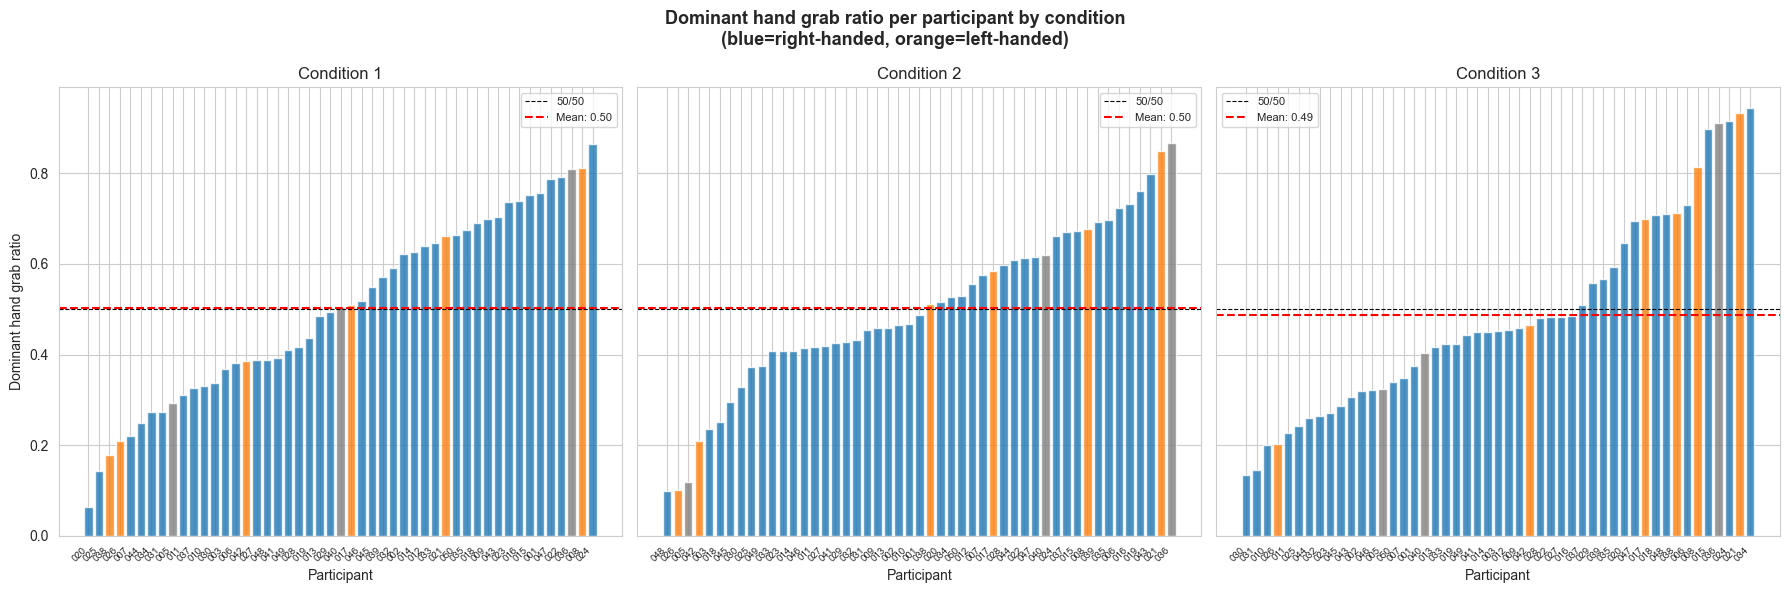


Mean dominant ratio by condition and handedness:
                              mean    std  count
condition_number handedness                     
1                left        0.459  0.251      6
                 right       0.508  0.201     40
2                left        0.489  0.284      6
                 right       0.501  0.156     40
3                left        0.638  0.263      6
                 right       0.460  0.201     40


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

condition_labels = {1: "Condition 1", 2: "Condition 2", 3: "Condition 3"}
colors = {"right": "tab:blue", "left": "tab:orange"}

for i, cond in enumerate([1, 2, 3]):
    ax = axes[i]
    cond_data = grab_counts_cond[grab_counts_cond["condition_number"] == cond].sort_values("dominant_ratio")
    bar_cols = [colors.get(h, "grey") for h in cond_data["handedness"]]
    
    ax.bar(cond_data["participant_id"], cond_data["dominant_ratio"], color=bar_cols, alpha=0.8)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="50/50")
    ax.axhline(cond_data["dominant_ratio"].mean(), color="red", linestyle="--",
               label=f'Mean: {cond_data["dominant_ratio"].mean():.2f}')
    ax.set_title(condition_labels[cond], fontsize=12)
    ax.set_xlabel("Participant")
    ax.set_xticklabels(cond_data["participant_id"], rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=8)
    if i == 0:
        ax.set_ylabel("Dominant hand grab ratio")

plt.suptitle("Dominant hand grab ratio per participant by condition\n(blue=right-handed, orange=left-handed)", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Summary stats per condition and handedness ---
print("\nMean dominant ratio by condition and handedness:")
print(
    grab_counts_cond.groupby(["condition_number", "handedness"])["dominant_ratio"]
    .agg(["mean", "std", "count"])
    .round(3)
)

In [ ]:
# Mean and std of left and right hand grab per condition and handedness
print("\nMean grab counts by condition and handedness:")
print(
    grab_counts_cond.groupby(["condition_number", "handedness"])[["left_grabs", "right_grabs"]]
    .agg(["mean", "std"])
    .round(3)
)


Mean grab counts by condition and handedness:
                            left_grabs         right_grabs         
                                  mean     std        mean      std
condition_number handedness                                        
1                left           83.167  46.227     115.667   71.195
                 right          94.275  58.266     100.025   64.972
2                left          100.000  78.694     122.833  104.826
                 right         110.600  40.157     121.250   72.657
3                left          141.833  68.204      98.833  100.031
                 right         114.375  50.275     104.150   62.403


In [ ]:
from scipy import stats

for cond in [1, 2, 3]:
    data = grab_counts_cond[grab_counts_cond["condition_number"] == cond]["dominant_ratio"].dropna()
    stat, p = stats.shapiro(data)
    print(f"Condition {cond}: Shapiro-Wilk p={p:.3f} — {'normal' if p > 0.05 else 'NOT normal'}")

Condition 1: Shapiro-Wilk p=0.189 — normal
Condition 2: Shapiro-Wilk p=0.412 — normal
Condition 3: Shapiro-Wilk p=0.034 — NOT normal


/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_45870/3551308466.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(per_p["participant_id"], rotation=45, ha="right")
/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_45870/3551308466.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_per_p, labels=participants, patch_artist=True)


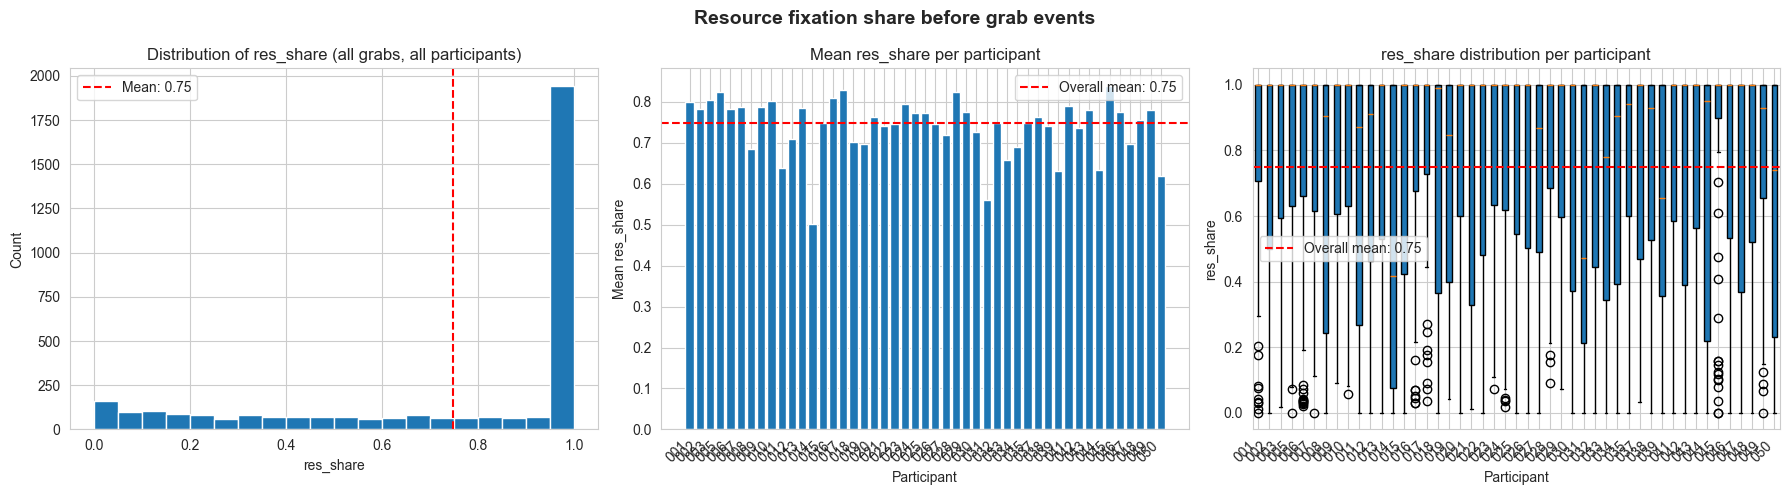

Overall mean res_share: 0.749
Overall median res_share: 1.000
Overall std: 0.343

Per participant means:
participant_id
001    0.799
002    0.782
003    0.806
005    0.825
006    0.782
007    0.788
008    0.686
009    0.787
010    0.802
011    0.639
012    0.710
013    0.786
014    0.501
015    0.748
016    0.811
017    0.828
018    0.702
019    0.698
020    0.762
021    0.742
022    0.746
023    0.796
024    0.772
025    0.773
026    0.746
027    0.720
028    0.824
029    0.776
030    0.725
031    0.559
032    0.749
033    0.657
034    0.689
035    0.749
037    0.762
038    0.741
039    0.630
041    0.790
042    0.736
043    0.781
044    0.635
045    0.840
046    0.776
047    0.696
048    0.756
049    0.781
050    0.619


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Distribution of res_share across all grabs ---
axes[0].hist(
    summary_all["res_share"].dropna(),
    bins=20, edgecolor="white"
)
axes[0].axvline(summary_all["res_share"].mean(), color="red", linestyle="--", label=f'Mean: {summary_all["res_share"].mean():.2f}')
axes[0].set_title("Distribution of res_share (all grabs, all participants)")
axes[0].set_xlabel("res_share")
axes[0].set_ylabel("Count")
axes[0].legend()

# --- Plot 2: Mean res_share per participant ---
per_p = summary_all.groupby("participant_id")["res_share"].mean().reset_index()
axes[1].bar(per_p["participant_id"], per_p["res_share"], edgecolor="white")
axes[1].axhline(summary_all["res_share"].mean(), color="red", linestyle="--", label=f'Overall mean: {summary_all["res_share"].mean():.2f}')
axes[1].set_title("Mean res_share per participant")
axes[1].set_xlabel("Participant")
axes[1].set_ylabel("Mean res_share")
axes[1].set_xticklabels(per_p["participant_id"], rotation=45, ha="right")
axes[1].legend()

# --- Plot 3: Boxplot per participant ---
participants = summary_all["participant_id"].unique()
data_per_p = [summary_all[summary_all["participant_id"] == p]["res_share"].dropna().values for p in participants]
axes[2].boxplot(data_per_p, labels=participants, patch_artist=True)
axes[2].axhline(summary_all["res_share"].mean(), color="red", linestyle="--", label=f'Overall mean: {summary_all["res_share"].mean():.2f}')
axes[2].set_title("res_share distribution per participant")
axes[2].set_xlabel("Participant")
axes[2].set_ylabel("res_share")
axes[2].set_xticklabels(participants, rotation=45, ha="right")
axes[2].legend()

plt.suptitle("Resource fixation share before grab events", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Print summary stats ---
print(f"Overall mean res_share: {summary_all['res_share'].mean():.3f}")
print(f"Overall median res_share: {summary_all['res_share'].median():.3f}")
print(f"Overall std: {summary_all['res_share'].std():.3f}")
print("\nPer participant means:")
print(per_p.set_index("participant_id")["res_share"].round(3).to_string())